In [1]:
CONFIG = \
"""
---
path_to_data: &path_to_data "/home/plotnikovgp/baikal/data/baikal_reco_reco_h8s2_norm.h5"

model_type: "encoder"
model_params:
  in_features: 5
  hidden_size: &hidden_size 512
  num_layers: &num_layers 5
  dim_feedforward_size: &dff 512
  n_heads: &n_heads 1
  out_size: 3
  dropout_p: 0.0
  use_cls_token: True
  return_only_cls_token: True


lr: 1.0e-4
batch_size: &batch_size 128
accumulate_grad_steps: 1
tres_cut: 100000.0
num_train_steps_per_validation: 250
grad_clip_value: 1.0

val_subset_cut: 30
warmup_steps: 10000
events_amount: 10000000
"""

In [2]:
import numpy as np

In [3]:
import torch
import torch.nn as nn


class BatchNorm1dTranspose(nn.BatchNorm1d):
    def forward(self, x):
        return super().forward(x.permute(0, 2, 1)).permute(0, 2, 1)


class TransformerEncoderLayerBN(nn.TransformerEncoderLayer):
    def __init__(self, d_model, *args, **kwargs):
        super().__init__(d_model, *args, **kwargs)
        self.norm1 = BatchNorm1dTranspose(d_model)
        self.norm2 = BatchNorm1dTranspose(d_model)



class Encoder(nn.Module):
    def __init__(
        self,
        in_features,
        hidden_size,
        num_layers,
        dim_feedforward_size,
        n_heads,
        out_size,
        dropout_p,
        use_batch_norm=False,
        second_head_out_size=None,
        use_cls_token=False,
        return_only_cls_token=False,
        return_hidden=False,
        **kwargs
    ):
        super().__init__()
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.hidden_size = hidden_size
        self.first_layer = nn.Linear(in_features, hidden_size)
        if not use_batch_norm:
            enc_layer = nn.TransformerEncoderLayer(
                hidden_size, n_heads, dim_feedforward_size, dropout_p, batch_first=True
            )
        else:
            enc_layer = TransformerEncoderLayerBN(
                hidden_size, n_heads, dim_feedforward_size, dropout_p, batch_first=True
            )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers)
        self.head = nn.Linear(hidden_size, out_size, bias=False)

        self.class_token = (
            nn.Parameter(
                torch.randn(1, 1, hidden_size),
                requires_grad=True,
            )
            if use_cls_token
            else None
        )
        self.return_only_cls_token = return_only_cls_token
        self.second_head = (
            nn.Linear(hidden_size, second_head_out_size)
            if second_head_out_size is not None
            else None
        )
        self.return_hidden = return_hidden

    def forward(self, x, mask):
        mask = (~mask).float()  # bool mask makes encoder predict nans sometimes
        x = self.first_layer(x)
        if self.class_token is not None:
            x = torch.cat([self.class_token.expand(x.shape[0], -1, -1), x], dim=1)
            mask = torch.cat(
                [torch.ones(x.shape[0], 1, dtype=torch.float32).to(mask.device), mask],
                dim=1,
            )
        x = self.enc(x, src_key_padding_mask=mask)
        y = self.head(x)
        res = y
        if self.second_head is not None:
            z = self.second_head(x)
            res = torch.cat([y.mean(1), z.mean(1)], dim=-1)
        elif self.class_token is not None and self.return_only_cls_token:
            res = y.mean(1) # [:, 0, :]
        return res if not self.return_hidden else (res, x)

In [4]:
from scipy.spatial.distance import pdist

def calc_track_length(x, y, z, is_track_mask):
    if is_track_mask.sum() < 2:
        return 0
    x = np.array(x[is_track_mask])
    y = np.array(y[is_track_mask])
    z = np.array(z[is_track_mask])
    points = np.stack((x, y, z), axis=-1)
    
    distances = pdist(points, 'euclidean')
    farthest_distance = np.max(distances)
    
    return float(farthest_distance)

In [5]:
import numpy as np
import h5py as h5
import torch
from torch.utils.data import Dataset, Subset, DataLoader
import logging
import math
import typing as tp

MAX_SEQ_LEN = 256


class BaikalDataset(Dataset):
    def __init__(
        self,
        data_file: str,
        split_type: str,
        batch_size: int,
        preprocessor,
        set_tres_stats: bool = False,
        *args,
        **kwargs,
    ) -> None:
        """
        Args:
            data_file (str): path to .h5 file
            split_type (str): train/val/test
        """
        self.path_to_data_file = data_file
        self.hfile = h5.File(data_file, "r")
        self.split_type = split_type
        self.events_amount = self.hfile[self.split_type + "/ev_starts/data"].shape[0] - 1
        mean, std = self.hfile['norm_param/mean'], self.hfile['norm_param/std']

        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)
        
        self.preprocessor = preprocessor
        self.batch_size = batch_size

    def _collate(
        self, event_starts, raw_data_x, raw_data_y=None, max_length=MAX_SEQ_LEN, pad_y=False,
        ):
        batch_x = []
        batch_y = []
        seq_lengths = []
        global_start = event_starts[0]

        track_lengths = []
        
        for i in range(len(event_starts) - 1):
            start = event_starts[i] - global_start
            end = event_starts[i + 1] - global_start
            length = min(end - start, max_length)
            x = torch.tensor(raw_data_x[start:start + length])
            batch_x.append(x)
            seq_lengths.append(length)
            if raw_data_y is not None:
                y = torch.tensor(raw_data_y[start:start + length])
                batch_y.append(y)
                xn = x[:, :5] * self.std + self.mean
                length = calc_track_length(xn[:, 2], xn[:, 3], xn[:, 4], y)
                track_lengths.append(length)

        data_x = torch.nn.utils.rnn.pad_sequence(batch_x, batch_first=True, padding_value=0)
        data_y = torch.nn.utils.rnn.pad_sequence(batch_y, batch_first=True, padding_value=0) if batch_y else None
        mask = torch.zeros(data_x.shape[0], data_x.shape[1], dtype=torch.bool)
        for i, length in enumerate(seq_lengths):
            mask[i, :length] = 1
        return data_x, data_y, mask, track_lengths

    def __len__(self):
        return self.events_amount // self.batch_size + 1
        

class BaikalDatasetAngles(BaikalDataset):
    def __getitem__(self, idx):
        batch_start_idx = idx * self.batch_size
        batch_end_idx = min((idx + 1) * self.batch_size, len(self.hfile[self.split_type + "/ev_starts/data"]) - 1)
        event_starts = self.hfile[self.split_type + "/ev_starts/data"][batch_start_idx:batch_end_idx + 1]
        
        prime_prty = torch.tensor(self.hfile[self.split_type + "/prime_prty/data"][batch_start_idx:batch_end_idx])
        # muon_prty = torch.tensor(self.hfile[self.split_type + '/muons_prty/individ/data'][batch_start_idx:batch_end_idx])
        # direction_prty = torch.cat((prime_prty[:, :2], muon_prty[:, 2:5]), -1)
        direction_prty = prime_prty[:, :2]
        global_start = event_starts[0]
        global_end = event_starts[-1]
        raw_data = torch.tensor(self.hfile[self.split_type + "/data/data"][global_start:global_end])

        tres = torch.tensor(self.hfile[self.split_type + "/t_res/data"][global_start:global_end]).abs()
        hits_labels = torch.tensor(self.hfile[self.split_type + "/labels/data"][global_start:global_end])
        is_track_hit = (hits_labels < 0) | (torch.abs(tres) < 10)
        ones = torch.ones(raw_data.shape[0], 1)
        # raw_data = torch.cat((raw_data, ones), -1)
        data_x, _, mask, track_lengths = self._collate(event_starts, raw_data, is_track_hit, pad_y=False)

        track_lengths_by_tres = {}
        for tres_lim in [0, 10, 20]:
            is_track_hit = (hits_labels < 0) | (torch.abs(tres) < tres_lim)
            _, _, _, track_lengths = self._collate(event_starts, raw_data, is_track_hit, pad_y=False)
            track_lengths_by_tres[tres_lim] = track_lengths
            
        # data_y: [batch_size, 5]              
        event_properties = {
            "num_strings": torch.tensor(self.hfile[self.split_type + "/num_un_strings/data"][batch_start_idx:batch_end_idx], dtype=torch.int32),
            "num_events": mask.sum(1),
            "energy": prime_prty[:, 2],
            "track_lengths": torch.tensor(track_lengths),
            "track_lengths_by_tres": {k: torch.tensor(v) for k, v in track_lengths_by_tres.items()},
            "reco_angles": torch.tensor(self.hfile[self.split_type + "/reco_ev/data"][batch_start_idx:batch_end_idx, 7:9], dtype=torch.float32),
            "reco_track_lengths": torch.tensor(self.hfile[self.split_type + "/reco_ev/data"][batch_start_idx:batch_end_idx, -1], dtype=torch.float32),
        }
        
        return self.preprocessor(data_x, direction_prty, mask), event_properties


class BaikalDatasetAnglesOld(BaikalDataset):
    def __getitem__(self, idx):
        # print(self.hfile)
        mask_len = int(np.sum(self.hfile[f"{self.split_type}/mask"][idx], axis =-1))
        data = np.array(self.hfile[self.split_type + "/data"][idx][:mask_len])
        thetha, phi = self.hfile[self.split_type + "/ev_chars"][idx][:2]

        thetha = float(thetha) * math.pi / 180
        phi = float(phi) * math.pi / 180
        vec = [math.sin(thetha) * math.cos(phi), math.sin(thetha) * math.sin(phi), math.cos(thetha)]

        data_x = torch.tensor(data, dtype=torch.float32)
        data_y = torch.tensor(vec, dtype=torch.float32)
        # data_y /= data_y.norm()
        event_properties = {
            "num_strings": torch.tensor(self.hfile[self.split_type + "/num_un_strings/data"][batch_start_idx:batch_end_idx], dtype=torch.int32),
            "num_hits": mask.sum(1),
            "energy": prime_prty[:, 2],
        }
        return self.preprocessor(data_x, data_y)
        # return res

In [7]:
class AnglePreprocessor:
    def __call__(
        self, x: torch.Tensor, y: torch.Tensor, mask: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        y = y[:, :2]
        thetha = torch.deg2rad(y[:, 0])
        phi = torch.deg2rad(y[:, 1])
        # print(y.shape, thetha.min(), thetha.max(), phi.min(), phi.max())
        direction = torch.zeros(y.shape[0], 3, dtype=torch.float32)
        direction[:, 0] = torch.sin(thetha) * torch.cos(phi)
        direction[:, 1] = torch.sin(thetha) * torch.sin(phi)
        direction[:, 2] = torch.cos(thetha)
        return x, direction, mask


class DirectionPreprocessor:
    def __call__(
        self, x: torch.Tensor, y: torch.Tensor, mask: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        points = y[:, 2:5]
        thetha = torch.deg2rad(y[:, 0])
        phi = torch.deg2rad(y[:, 1])
        # print(y.shape, thetha.min(), thetha.max(), phi.min(), phi.max())
        angle = torch.zeros(y.shape[0], 3, dtype=torch.float32)
        angle[:, 0] = torch.sin(thetha) * torch.cos(phi)
        angle[:, 1] = torch.sin(thetha) * torch.sin(phi)
        angle[:, 2] = torch.cos(thetha)
        angle_and_point = torch.cat((angle, points), -1)
        return x, angle_and_point, mask

In [8]:
DEVICE = "cuda"

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class UncertaintyPredictor(nn.Module):
    def __init__(self, model: Encoder):
        super().__init__()
        self.device = "cuda"
        self.model = model.eval()
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.return_hidden = True
        self.predictor = nn.Sequential(
            nn.Linear(model.hidden_size, model.hidden_size),
            nn.ReLU(),
            nn.Linear(model.hidden_size, 3),
        )
        
    def forward(self, x, mask):
        with torch.no_grad():
            x, hidden = self.model(x, mask)
        x = x / x.norm(dim=1, keepdim=True)
        log_sigma = self.predictor(hidden).mean(1)
        return torch.cat([x, log_sigma], dim=-1)


def uncertainty_loss(pred_and_log_sigma2, target):
    # pred_and_log_sigma2: B x (3 + 1)
    # target: B x 3
    pred, log_sigma2 = pred_and_log_sigma2[:, :3], pred_and_log_sigma2[:, 3:]
    pred_sigma2 = torch.exp(log_sigma2)
    # print(pred.shape, target.shape, log_sigma2.shape)

    squared_error = (pred - target) ** 2

    # NLL Loss for Gaussian: log(sigma^2) + [(y - mu)^2 / sigma^2]
    loss = torch.mean(log_sigma2 + squared_error / pred_sigma2)
    return loss


In [10]:
import yaml
# with open(CONFIG, "r") as f:
train_params = yaml.safe_load(CONFIG)

In [11]:
train_params

{'path_to_data': '/home/plotnikovgp/baikal/data/baikal_reco_reco_h8s2_norm.h5',
 'model_type': 'encoder',
 'model_params': {'in_features': 5,
  'hidden_size': 512,
  'num_layers': 5,
  'dim_feedforward_size': 512,
  'n_heads': 1,
  'out_size': 3,
  'dropout_p': 0.0,
  'use_cls_token': True,
  'return_only_cls_token': True},
 'lr': 0.0001,
 'batch_size': 128,
 'accumulate_grad_steps': 1,
 'tres_cut': 100000.0,
 'num_train_steps_per_validation': 250,
 'grad_clip_value': 1.0,
 'val_subset_cut': 30,
 'warmup_steps': 10000,
 'events_amount': 10000000}

In [12]:
DEVICE = "cuda"

In [26]:
with open("../train_configs/encoder_track_cascade.yaml", "r") as f:
    track_cascade_params = yaml.safe_load(f)
track_cascade_model = Encoder(**track_cascade_params["model_params"])
track_cascade_model.load_state_dict(
    torch.load("/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/checkpoints/track_cascade_enc_hyps_mc_0924/encoder_nl5_dff512_hs512_try_on_other_data/best.ckpt")
)
track_cascade_model.to(DEVICE)
track_cascade_model.eval()

Encoder(
  (first_layer): Linear(in_features=5, out_features=512, bias=True)
  (enc): TransformerEncoder(
    (layers): ModuleList(
      (0-4): 5 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=512, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (head): Linear(in_features=512, out_features=2, bias=False)
)

In [13]:
model = Encoder(**train_params["model_params"])
model.load_state_dict(torch.load("/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/checkpoints/angle_reconstruction_combine_reco_mc/encoder_nl5_hs512_dff512_nh1_lr1e4_bs128_nm250_wr5_wm5/best_reco.ckpt"))

/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


<All keys matched successfully>

In [14]:
model = model.to(DEVICE)

n_params = np.sum(p.numel() for p in model.parameters())
print("n_params M", n_params / 1e6)

n_params M 7.89504


/tmp/ipykernel_2184799/2080352119.py:3: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  n_params = np.sum(p.numel() for p in model.parameters())


### Uncertainty predictor

In [17]:
# encoder_model = Encoder(**train_params["encoder_model_params"])
# encoder_model.load_state_dict(torch.load(train_params["encoder_model_path"]))
# encoder_model = encoder_model.to(DEVICE)
# model = UncertaintyPredictor(encoder_model)
# model.load_state_dict(
#     torch.load("/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/checkpoints/angle_reconstruction_sigma_v5_mc_0924/encoder_nl5_hs512_dff512_nh1_lr1e4_no-eas_10-3_mae_sigma_tune_new/best.ckpt"
#               )
# )
# model = model.to(DEVICE)

# n_params = np.sum(p.numel() for p in model.parameters())
# print("n_params M", n_params / 1e6)

In [18]:
# train_params

In [19]:
MODEL_PATH = "/home/plotnikovgp/baikal/Baikal-ML/pytorch_training/checkpoints/angle_reconstruction_exp_data_with_reco/encoder_nl5_hs128_dff512_nh2_lr1e4_with_track_hits_mask_nm500/best.ckpt"

In [20]:
train_params["model_params"]["in_features"] = 5

In [21]:
model = Encoder(**train_params["model_params"])
model.load_state_dict(torch.load(MODEL_PATH))

<All keys matched successfully>

In [22]:
# encoder_model.return_hidden = True

In [23]:
# def cos_loss(y_pred, y_dist):
#     1 - torch.nn.functional.cosine_embedding_loss(y_pred, y_dist)

In [15]:
from tqdm import tqdm

In [16]:
def flexible_cat_dict(d_hist, d_new):
    if d_hist is None:
        return d_new
    out = {}
    for k in d_hist:
        if isinstance(d_hist[k], dict):
            out[k] = {}
            for sk in d_hist[k]:
                out[k][sk] = torch.cat((d_hist[k][sk], d_new[k][sk]), dim=0)
        else:  # assume tensor
            out[k] = torch.cat((d_hist[k], d_new[k]), dim=0)
    return out

In [27]:
def validate(
    model,
    val_loader,
    criterion,
    scheduler=None,
    metrics_calc_fun=None,
    return_preds=False,
    track_cascade_model=None,
) -> dict[str, float]:
    y_pred_hist = None
    y_true_hist = None
    loss_hist = []
    sigma_hist = []
    dist_hist = []
    event_properties_hist = None
    model.eval()
    with torch.no_grad():
        for data in tqdm(val_loader, total=len(val_loader)):
            (x, y_true, mask), event_properties = data
            xn = x * dataset.std + dataset.mean
            x, y_true, mask = (
                x.to(model.device),
                y_true.to(model.device),
                mask.to(model.device),
            )
            if track_cascade_model:
                with torch.no_grad():
                    track_prob = 1 - torch.sigmoid(track_cascade_model(x, mask)[:, :, 1])
                    track_lengths_by_thr = {k: [] for k in [0.4, 0.5]}
                    mask_ = mask.detach().cpu()
                    track_prob = track_prob.detach().cpu()
                    for i in range(len(mask)):
                        for thr in track_lengths_by_thr:
                            is_track = (track_prob[i] >= thr)
                            m = mask_[i]
                            track_length = calc_track_length(xn[i, m, 2], xn[i, m, 3], xn[i, m, 4], is_track[m])
                            track_lengths_by_thr[thr].append(track_length)
                    track_lengths_by_thr = {k: torch.tensor(v) for k, v in track_lengths_by_thr.items()}
            output = model(x, mask)

            if output.shape[-1] == 6:
                output, log_sigma_pred = output[..., :3], output[..., 3:]
            else:
                # просто заглушка
                output = output, log_sigma_pred = output[..., :3], output[..., :3]
            sigma_pred = torch.exp(log_sigma_pred)
            output = output / output.norm(dim=1, keepdim=True)
            y_pred = output
                        
            loss = criterion(output, y_true)
            sigma_true = (output - y_true)**2 # 1 - F.cosine_similarity(output, y_true, dim=1)
            loss_hist.append(loss.item())
            
            sigma_hist.extend(sigma_true.detach().cpu().numpy().tolist())
            dist_hist.extend(sigma_pred.detach().cpu().numpy().tolist())
            
            y_pred_hist = (
                torch.cat((y_pred_hist, y_pred.detach().cpu()), dim=0)
                if y_pred_hist is not None
                else y_pred.detach().cpu()
            )
            y_true_hist = (
                torch.cat((y_true_hist, y_true.detach().cpu()), dim=0)
                if y_true_hist is not None
                else y_true.detach().cpu()
            )
            event_properties['track_lengths_pred_by_thr'] = track_lengths_by_thr
            event_properties_hist = flexible_cat_dict(event_properties_hist, event_properties)
    if return_preds:
        return y_pred_hist, y_true_hist, event_properties_hist, dist_hist, sigma_hist
    
    val_mertics = metrics_calc_fun(y_pred_hist, y_true_hist)
    val_mertics["loss"] = sum(loss_hist) / len(loss_hist) if loss_hist else None
    if val_mertics["loss"] and scheduler:
        scheduler.step(val_mertics["loss"])

    
    return val_mertics

In [28]:
train_params["path_to_data"]

'/home/plotnikovgp/baikal/data/baikal_reco_reco_h8s2_norm.h5'

In [31]:
# def collate_fn(batch):
#     x_batch = pad_sequence([x[0] for x in batch], batch_first=True)
#     y_batch = pad_sequence(
#         [x[1] for x in batch],
#         batch_first=True,
#     )
#     padding_mask = (x_batch > 0).sum(-1)
#     padding_mask[padding_mask != 0] = 1
#     return x_batch, y_batch.squeeze(-1), padding_mask.bool()

dataset = BaikalDatasetAngles(
    data_file=train_params["path_to_data"],
    # data_file="/home/plotnikovgp/baikal/data/baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed.h5",
    split_type='test',
    batch_size=256,
    #collator=collate_fn,
    preprocessor=AnglePreprocessor(),
)
subset = Subset(dataset, list(range(0, len(dataset), 1)))

In [32]:
train_params["path_to_data"]

'/home/plotnikovgp/baikal/data/baikal_reco_reco_h8s2_norm.h5'

In [33]:
train_dataset = BaikalDatasetAngles(
    data_file=train_params["path_to_data"],
    # data_file="/home/plotnikovgp/baikal/data/baikal_mc2020_multi_split_0924_MChits-8-2_normed.h5",
    split_type='train',
    batch_size=128,
    #collator=collate_fn,
    preprocessor=AnglePreprocessor(),
)
train_subset = Subset(train_dataset, list(range(0, len(dataset), 1)))

In [34]:
import matplotlib.pyplot as plt

In [35]:
%matplotlib widget

In [36]:
def criterion(y_pred, y_true):
    # maximize average magnitude of cosine similarity
    return 1 - torch.nn.functional.cosine_similarity(y_pred, y_true).mean()

In [37]:
from tqdm import tqdm

In [38]:
model.to(DEVICE).eval()
pass

In [39]:
y_pred_hist, y_true_hist, event_properties_hist, sigma_pred_hist, sigma_true_hist = validate(
    model, val_loader=subset, criterion=criterion, return_preds=True, track_cascade_model=track_cascade_model
)

  0%|                                                                                                                                                                                      | 0/232 [00:00<?, ?it/s]/tmp/ipykernel_2184799/2782491134.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(raw_data_x[start:start + length])
/tmp/ipykernel_2184799/2782491134.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(raw_data_y[start:start + length])
/home/plotnikovgp/tmp/ENTER/lib/python3.11/site-packages/torch/nn/modules/transformer.py:380: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered

In [40]:
len(subset) * 128

29696

In [167]:
sigma_pred_hist = np.array(sigma_pred_hist) # .shape
sigma_true_hist = np.array(sigma_true_hist) 
sigma_pred_hist.shape, sigma_true_hist.shape

((99968, 3), (99968, 3))

In [41]:
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_percentage_error,
    mean_absolute_error,
)
from scipy.spatial.distance import cosine as cosine_dist

In [42]:
import matplotlib.pyplot as plt

In [43]:
print(event_properties_hist['reco_track_length'].max())

KeyError: 'reco_track_length'

In [44]:
track_lengths_pred = event_properties_hist["track_lengths"]

In [45]:
import matplotlib.pyplot as plt

In [46]:
plt.style.use('seaborn-v0_8-darkgrid')

In [47]:
cut_test = (event_properties_hist["num_strings"] >= 2) & (event_properties_hist["num_events"] >= 8)
cut_test.sum()

tensor(59310)

In [48]:
len(event_properties_hist["num_strings"])

59310

In [63]:

def extract_angles(vector):
    x, y, z = vector
    theta = np.arccos(z)
    phi = np.arctan2(y, x)
    
    # Convert from radians to degrees
    theta_deg = np.rad2deg(theta)
    phi_deg = np.rad2deg(phi)
    
    # Ensure phi is in the range [0, 360)
    phi_deg = phi_deg % 360
    
    return theta_deg, phi_deg

def angle_reconstruction_metrics(y_pred, y_true, return_vec_metrics=False):
    y_pred = np.array(y_pred, dtype=np.float32)
    y_true = np.array(y_true, dtype=np.float32)
    metrics = {}
    vec_metrics = {}
    # metrics.update(regression_metrics(y_pred, y_true))

    angles_true = np.array([extract_angles(vec) for vec in y_true], dtype=np.float32)
    angles_pred = np.array([extract_angles(vec) for vec in y_pred], dtype=np.float32)
    y_true_theta_angle, y_true_phi_angle = angles_true[:, 0], angles_true[:, 1]
    y_pred_theta_angle, y_pred_phi_angle = angles_pred[:, 0], angles_pred[:, 1]
    
    if not np.isnan(y_pred_theta_angle).any() and not np.isnan(y_pred_phi_angle).any():
        metrics["theta_mae"] = mean_absolute_error(
            y_true_theta_angle, y_pred_theta_angle
        )
        
        # Calculate phi difference considering circular nature (0° and 360° are the same)
        phi_diff = np.abs(y_true_phi_angle - y_pred_phi_angle)
        phi_diff = np.minimum(phi_diff, 360 - phi_diff)
        metrics["phi_mae"] = np.mean(phi_diff)
        
        theta_resolution = np.abs(y_true_theta_angle - y_pred_theta_angle)
        phi_resolution = phi_diff  # Using the circular difference for phi

        dot_product = np.sum(y_true * y_pred, axis=1)
        dot_product = np.clip(dot_product, -1.0, 1.0)
        dir_resolution = np.abs(np.rad2deg(np.arccos(dot_product)))
        
        metrics["theta_resolution_q50"] = np.quantile(theta_resolution, 0.5)
        metrics["theta_resolution_q68"] = np.quantile(theta_resolution, 0.68)
        
        metrics["phi_resolution_q50"] = np.quantile(phi_resolution, 0.5)
        metrics["phi_resolution_q68"] = np.quantile(phi_resolution, 0.68)
        metrics["dir_resolution_q50"] = np.quantile(dir_resolution, 0.5)
        metrics["dir_resolution_q68"] = np.quantile(dir_resolution, 0.68)

        vec_metrics["theta_resolution_all"] = theta_resolution
        vec_metrics["phi_resolution_all"] = phi_resolution
        vec_metrics["dir_resolution_all"] = dir_resolution
        vec_metrics["theta_resolution_all"] = theta_resolution
        vec_metrics["phi_resolution_all"] = phi_resolution
        vec_metrics["dir_resolution_all"] = dir_resolution
        vec_metrics["y_true_theta_angle"] = y_true_theta_angle
        vec_metrics["y_pred_theta_angle"] = y_pred_theta_angle
        vec_metrics["y_true_theta_angle"] = y_true_theta_angle
        vec_metrics["y_pred_phi_angle"] = y_pred_phi_angle
        vec_metrics["y_true_phi_angle"] = y_true_phi_angle
        
    scalar_metrics = {k: float(v) for k, v in metrics.items()}
    return scalar_metrics if not return_vec_metrics else scalar_metrics, vec_metrics


In [64]:
import numpy as np
import matplotlib.pyplot as plt


In [72]:
track_cut = -1
cut = (event_properties_hist["track_lengths"] >= track_cut)
_, y_pred_reco_hist, _ =  AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
scalar_metrics, vec_metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], True)
scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], True)

In [73]:
scalar_metrics_reco

{'theta_mae': 6.386655330657959,
 'phi_mae': 22.050630569458008,
 'theta_resolution_q50': 1.231459617614746,
 'theta_resolution_q68': 2.8126452636718757,
 'phi_resolution_q50': 3.1841812133789062,
 'phi_resolution_q68': 13.416297607421882,
 'dir_resolution_q50': 3.1871180534362793,
 'dir_resolution_q68': 10.826306037902834}

In [67]:
vec_metrics.keys()

dict_keys(['theta_resolution_all', 'phi_resolution_all', 'dir_resolution_all', 'y_true_theta_angle', 'y_pred_theta_angle', 'y_pred_phi_angle', 'y_true_phi_angle'])

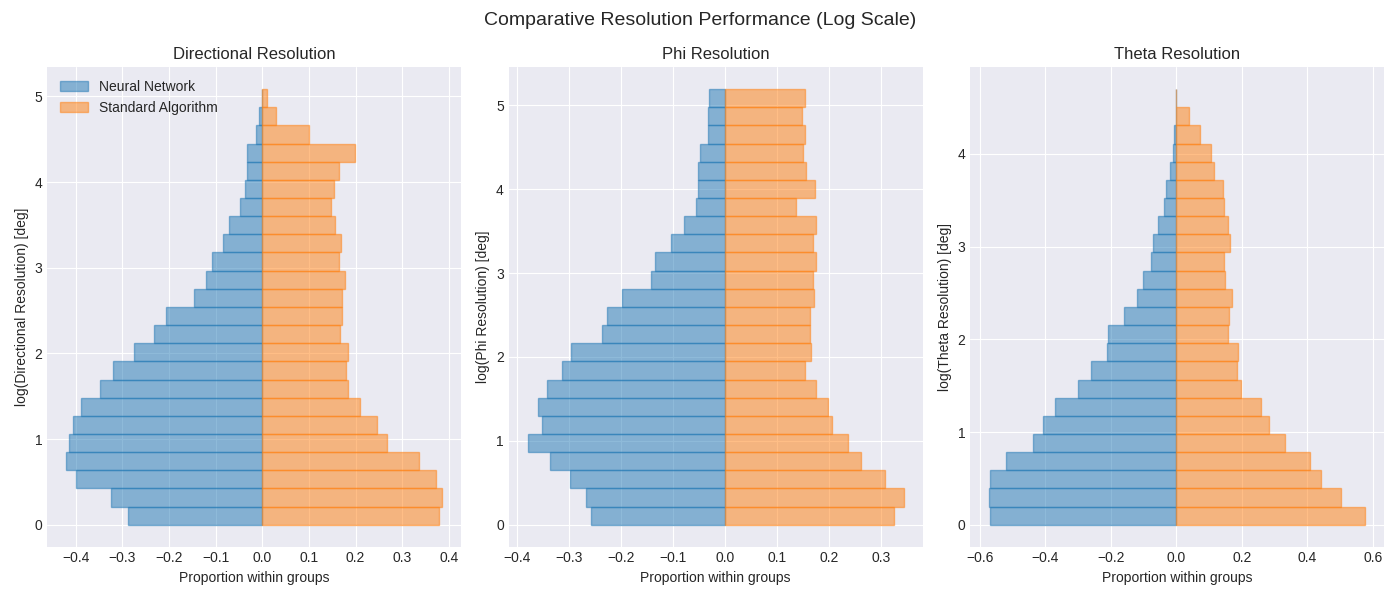

In [128]:

track_cut = 100
cut = (event_properties_hist["track_lengths"] >= track_cut)
_, y_pred_reco_hist, _ = AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
scalar_metrics, vec_metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], True)
scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], True)

# Create figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Variables to plot
variables = ['dir_resolution_all', 'phi_resolution_all', 'theta_resolution_all']
titles = ['Directional Resolution', 'Phi Resolution', 'Theta Resolution']

for i, (var, title) in enumerate(zip(variables, titles)):
    # Get data and apply logarithm
    x1 = np.log(np.array(vec_metrics[var]))
    x2 = np.log(np.array(vec_metrics_reco[var]))
    
    # x1 = np.array(vec_metrics[var])
    # x2 = np.array(vec_metrics_reco[var])
    
    bins = np.linspace(0, min(max(x1.max(), x2.max()), 90), 25)
    
    hist1, edges = np.histogram(x1, bins=bins, density=True)
    hist2, _ = np.histogram(x2, bins=bins, density=True)
    
    bin_centers = 0.5 * (edges[1:] + edges[:-1])
    
    # Plot on the corresponding subplot
    axes[i].barh(bin_centers, -hist1, height=(bins[1]-bins[0]), color='C0', 
                alpha=0.5, edgecolor='C0', label='Neural Network')
    axes[i].barh(bin_centers, hist2, height=(bins[1]-bins[0]), color='C1', 
                alpha=0.5, edgecolor='C1', label='Standard Algorithm')
    
    axes[i].set_xlabel('Proportion within groups')
    axes[i].set_ylabel('log(' + title + ') [deg]')
    axes[i].set_title(title)
    
    # Only add legend to the first plot to avoid redundancy
    if i == 0:
        axes[i].legend(loc='upper left')

fig.suptitle('Comparative Resolution Performance (Log Scale)', fontsize=14)
plt.tight_layout()
plt.show()
plt.savefig('plots/resolution_comparison.png')


/tmp/ipykernel_1806673/3938517200.py:16: RuntimeWarning: divide by zero encountered in log
  x1 = np.log(np.array(vec_metrics[var]))
/tmp/ipykernel_1806673/3938517200.py:17: RuntimeWarning: divide by zero encountered in log
  x2 = np.log(np.array(vec_metrics_reco[var]))


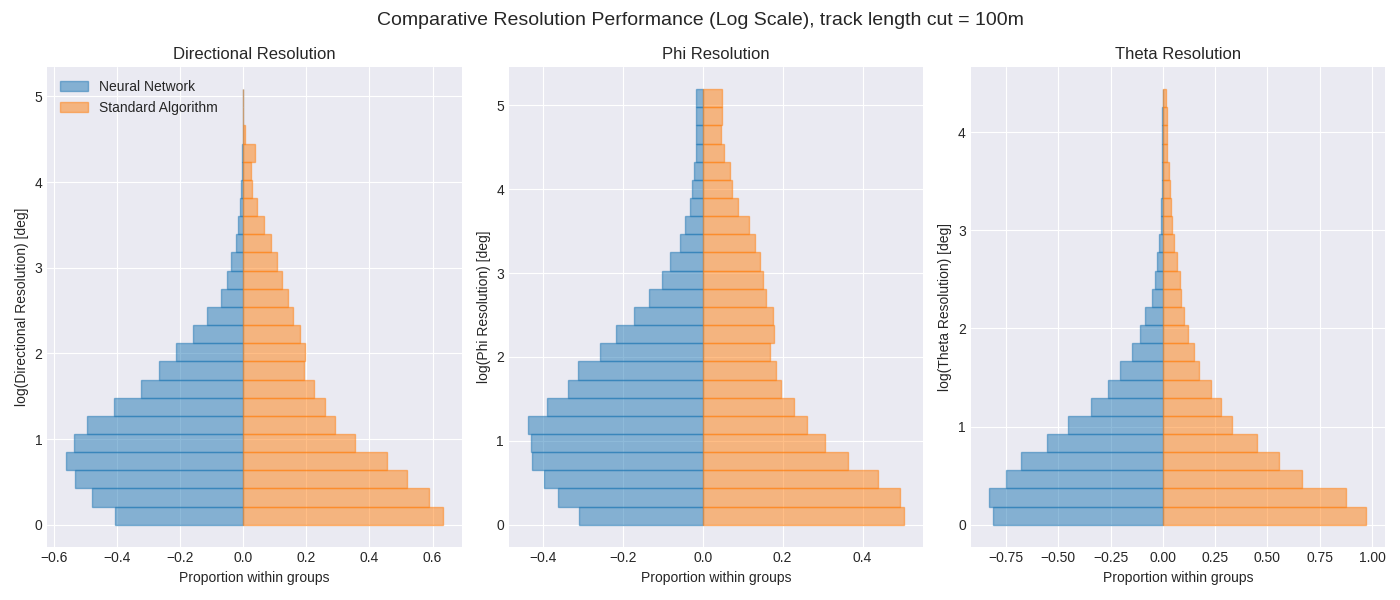

In [156]:
track_cut = 100
cut = (event_properties_hist["track_lengths"] >= track_cut)
_, y_pred_reco_hist, _ = AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
scalar_metrics, vec_metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], True)
scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], True)

# Create figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# Variables to plot
variables = ['dir_resolution_all', 'phi_resolution_all', 'theta_resolution_all']
titles = ['Directional Resolution', 'Phi Resolution', 'Theta Resolution']

for i, (var, title) in enumerate(zip(variables, titles)):
    # Get data and apply logarithm
    x1 = np.log(np.array(vec_metrics[var]))
    x2 = np.log(np.array(vec_metrics_reco[var]))
    
    # x1 = np.array(vec_metrics[var])
    # x2 = np.array(vec_metrics_reco[var])
    
    bins = np.linspace(0, min(max(x1.max(), x2.max()), 90), 25)
    
    hist1, edges = np.histogram(x1, bins=bins, density=True)
    hist2, _ = np.histogram(x2, bins=bins, density=True)
    
    bin_centers = 0.5 * (edges[1:] + edges[:-1])
    
    # Plot on the corresponding subplot
    axes[i].barh(bin_centers, -hist1, height=(bins[1]-bins[0]), color='C0', 
                alpha=0.5, edgecolor='C0', label='Neural Network')
    axes[i].barh(bin_centers, hist2, height=(bins[1]-bins[0]), color='C1', 
                alpha=0.5, edgecolor='C1', label='Standard Algorithm')
    
    axes[i].set_xlabel('Proportion within groups')
    axes[i].set_ylabel('log(' + title + ') [deg]')
    axes[i].set_title(title)
    
    # Only add legend to the first plot to avoid redundancy
    if i == 0:
        axes[i].legend(loc='upper left')

fig.suptitle(f'Comparative Resolution Performance (Log Scale), track length cut = {track_cut}m', fontsize=14)
plt.tight_layout()
plt.show()
plt.savefig('plots/resolution_comparison.png')


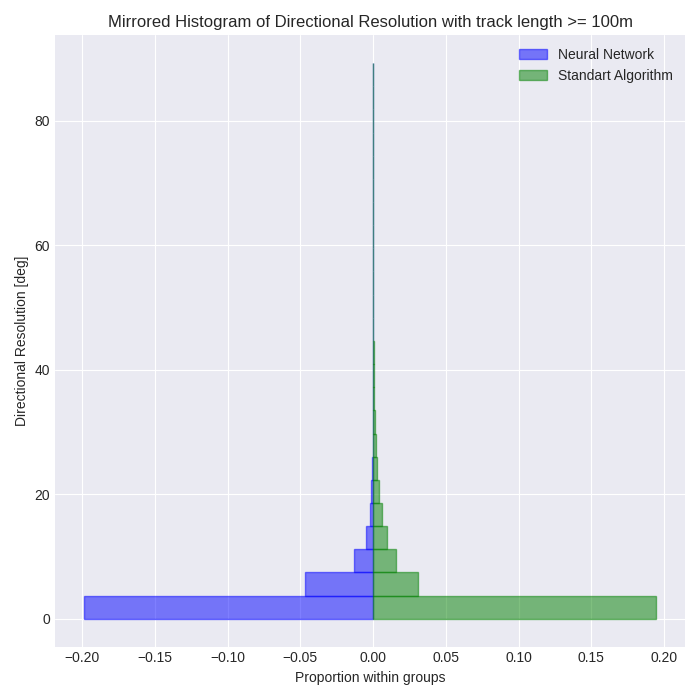

In [318]:
track_cut = 100
cut = (event_properties_hist["track_lengths"] >= track_cut)
_, y_pred_reco_hist, _ =  AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
scalar_metrics, vec_metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], True)
scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], True)

# Example data (replace with yours!)
x1 = np.array(vec_metrics['dir_resolution_all'])
x2 = np.array(vec_metrics_reco['dir_resolution_all'])

bins = np.linspace(0, min(max(x1.max(), x2.max()), 90), 25)

hist1, edges = np.histogram(x1, bins=bins, density=True)
hist2, _ = np.histogram(x2, bins=bins, density=True)

bin_centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(7, 7))
plt.barh(bin_centers, -hist1, height=(bins[1]-bins[0]), color='blue', alpha=0.5, edgecolor='blue', label='Neural Network')
plt.barh(bin_centers, hist2, height=(bins[1]-bins[0]), color='green', alpha=0.5, edgecolor='green', label='Standart Algorithm')
plt.xlabel('Proportion within groups')
plt.ylabel('Directional Resolution [deg]')
plt.legend(loc='upper right')
plt.title(f'Mirrored Histogram of Directional Resolution with track length >= {track_cut}m')
plt.tight_layout()
plt.show()
plt.savefig('plots/mirrored_hist.png')

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace with yours!)
x1 = np.array(vec_metrics['phi_resolution_all'])
x2 = np.array(vec_metrics_reco['phi_resolution_all'])

bins = np.linspace(0, min(max(x1.max(), x2.max()), 90), 25)

hist1, edges = np.histogram(x1, bins=bins, density=True)
hist2, _ = np.histogram(x2, bins=bins, density=True)

bin_centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(7, 7))
plt.barh(bin_centers, -hist1, height=(bins[1]-bins[0]), color='blue', alpha=0.5, edgecolor='blue', label='Neural Network')
plt.barh(bin_centers, hist2, height=(bins[1]-bins[0]), color='green', alpha=0.5, edgecolor='green', label='Standart Algorithm')
plt.xlabel('Proportion within groups')
plt.ylabel('Directional Resolution [deg]')
plt.legend(loc='upper right')
plt.title('Mirrored Histogram of Directional Resolution')
plt.tight_layout()
plt.show()
plt.savefig('plots/mirrored_hist.png')

NameError: name 'vec_metrics' is not defined

In [82]:
def quantile_ci(data, q, n_bootstrap=1000, ci=0.95, random_state=None):
    """
    Returns the quantile and its symmetric bootstrap confidence interval (center, lower, upper),
    where the lower and upper bounds are symmetric around the quantile.
    """
    data = np.asarray(data)
    rng = np.random.default_rng(random_state)
    bootstrapped = np.array([
        np.quantile(rng.choice(data, size=len(data), replace=True), q)
        for _ in range(n_bootstrap)
    ])
    center = np.quantile(data, q)
    # Asymmetric bounds
    lower = np.percentile(bootstrapped, 100 * (1 - ci) / 2)
    upper = np.percentile(bootstrapped, 100 * (1 + ci) / 2)
    # Symmetric deviation: take the maximum distance from center
    delta = max(center - lower, upper - center)
    return center, delta

In [83]:
theta_resolution = vec_metrics["thetha_resolution_all"]
phi_resolution   = vec_metrics["phi_resolution_all"]
dir_resolution   = vec_metrics["dir_resolution_all"]

In [84]:
ci_level = 0.95           # 90% confidence intervals, adjust as needed
n_bootstrap = 1000         # More is better, but 1000 is typical

for quantile_name, q in [('q50', 0.5), ('q68', 0.68)]:
    for name, arr in [('theta', theta_resolution), ('phi', phi_resolution), ('dir', dir_resolution)]:
        cen, delta = quantile_ci(arr, q, n_bootstrap=n_bootstrap, ci=ci_level)
        print(f"{name}_resolution_{quantile_name}: {cen:.3f}+-{delta:.3f}")

theta_resolution_q50: 1.333+-0.040
phi_resolution_q50: 3.604+-0.125
dir_resolution_q50: 3.338+-0.098
theta_resolution_q68: 2.433+-0.091
phi_resolution_q68: 7.028+-0.240
dir_resolution_q68: 5.909+-0.187


In [85]:
theta_resolution = vec_metrics_reco["thetha_resolution_all"]
phi_resolution   = vec_metrics_reco["phi_resolution_all"]
dir_resolution   = vec_metrics_reco["dir_resolution_all"]

In [87]:
ci_level = 0.95            # 90% confidence intervals, adjust as needed
n_bootstrap = 1000         # More is better, but 1000 is typical

for quantile_name, q in [('q50', 0.5), ('q68', 0.68)]:
    for name, arr in [('theta', theta_resolution), ('phi', phi_resolution), ('dir', dir_resolution)]:
        cen, delta = quantile_ci(arr, q, n_bootstrap=n_bootstrap, ci=ci_level)
        print(f"{name}_resolution_{quantile_name}: {cen:.3f}+-{delta:.3f}")

theta_resolution_q50: 1.208+-0.039
phi_resolution_q50: 3.207+-0.228
dir_resolution_q50: 3.139+-0.150
theta_resolution_q68: 2.721+-0.150
phi_resolution_q68: 13.868+-0.925
dir_resolution_q68: 10.703+-0.654


In [90]:
scalar_metrics_nn.keys()

dict_keys(['theta_mae', 'phi_mae', 'theta_resolution_q50', 'theta_resolution_q68', 'phi_resolution_q50', 'phi_resolution_q68', 'dir_resoultion_q50', 'dir_resoultion_q68'])

In [55]:
track_cut = -1
cut = (event_properties_hist["track_lengths"] >= track_cut)
_, y_pred_reco_hist, _ =  AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)

scalar_metrics, vec_metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], True)
scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], True)

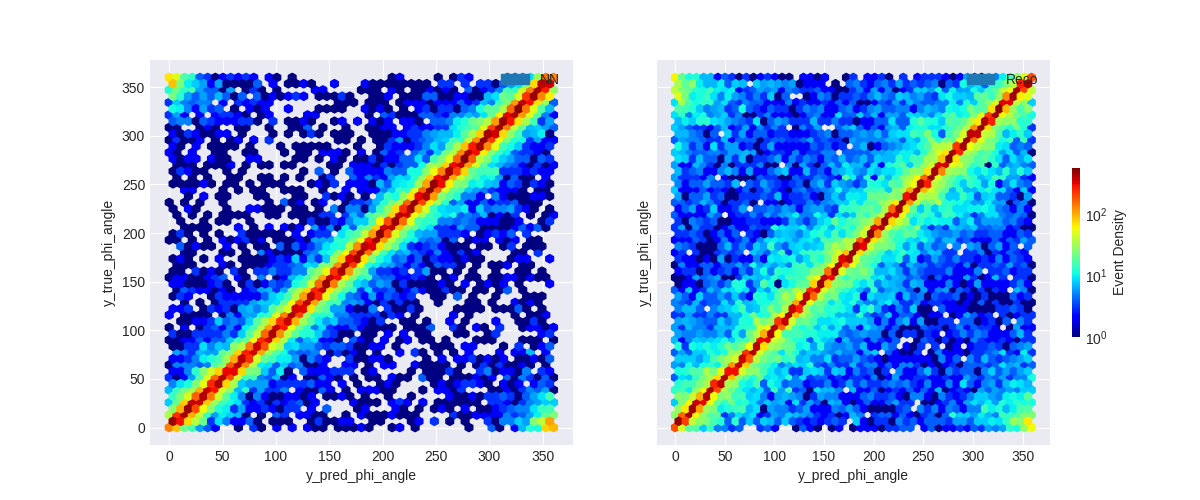

In [59]:
coords = ['x', 'y', 'z']
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5), sharex=True, sharey=True)

# for i, (coord, ax) in enumerate(zip(coords, axs)):
    # Compute sigma for each coordinate

hb1 = ax1.hexbin(vec_metrics["y_pred_phi_angle"], vec_metrics["y_true_phi_angle"], gridsize=50, cmap='jet', bins='log', label="NN")
hb2 = ax2.hexbin(vec_metrics_reco["y_pred_phi_angle"], vec_metrics_reco["y_true_phi_angle"], gridsize=50, cmap='jet', bins='log', label="Reco")

min_v = -8 # min(y_pred.min(), y_true.min())
max_v = 2 # max(y_pred.max(), y_true.max())
# ax.plot([min_v, max_v], [min_v, max_v], 'k--', lw=1.5, label='$y=x$')

ax1.set_xlabel("y_pred_phi_angle")
ax1.set_ylabel("y_true_phi_angle")
ax1.legend()
ax2.set_xlabel("y_pred_phi_angle")
ax2.set_ylabel("y_true_phi_angle")
ax2.legend()
    
# Add a single colorbar to the right
# cb1 = fig.colorbar(hb1, ax=ax1, orientation='vertical', fraction=0.02, pad=0.05)
# cb1.set_label('Event Density')

cb2 = fig.colorbar(hb2, ax=ax2, orientation='vertical', fraction=0.02, pad=0.05)
cb2.set_label('Event Density')
# fig.suptitle(rf'$\log \sigma_{{\mathrm{{true}}}}$ vs $\log \sigma_{{\mathrm{{pred}}}}$, for x, y, z components', fontsize=16)
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig("sigma_coords.png")
# plt.savefig("sigma_coords2.png", dpi=300)
# plt.plot()
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:12<00:00,  1.27it/s]


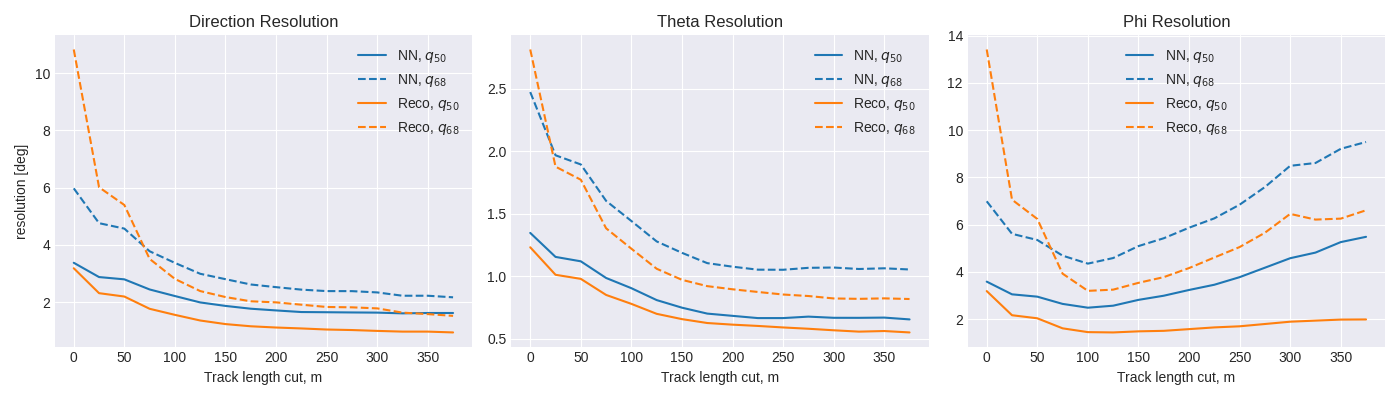

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

track_cuts = np.arange(0., 400., 25)

# Для хранения по track_cut
dirq50_nn, dirq68_nn = [], []
thetaq50_nn, thetaq68_nn = [], []
phiq50_nn, phiq68_nn = [], []

dirq50_reco, dirq68_reco = [], []
thetaq50_reco, thetaq68_reco = [], []
phiq50_reco, phiq68_reco = [], []

for track_cut in tqdm(track_cuts):
    cut = (event_properties_hist["track_lengths"] >= track_cut-0.01)
    # NN
    scalar_metrics_nn, vec_metrics_nn = angle_reconstruction_metrics(
        y_pred_hist[cut], y_true_hist[cut], True)
    dirq50_nn.append(scalar_metrics_nn['dir_resolution_q50'])
    dirq68_nn.append(scalar_metrics_nn['dir_resolution_q68'])
    thetaq50_nn.append(scalar_metrics_nn['theta_resolution_q50'])
    thetaq68_nn.append(scalar_metrics_nn['theta_resolution_q68'])
    phiq50_nn.append(scalar_metrics_nn['phi_resolution_q50'])
    phiq68_nn.append(scalar_metrics_nn['phi_resolution_q68'])
    # Reco
    _, y_pred_reco_hist, _ = AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
    scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(
        y_pred_reco_hist[cut], y_true_hist[cut], True)
    dirq50_reco.append(scalar_metrics_reco['dir_resolution_q50'])
    dirq68_reco.append(scalar_metrics_reco['dir_resolution_q68'])
    thetaq50_reco.append(scalar_metrics_reco['theta_resolution_q50'])
    thetaq68_reco.append(scalar_metrics_reco['theta_resolution_q68'])
    phiq50_reco.append(scalar_metrics_reco['phi_resolution_q50'])
    phiq68_reco.append(scalar_metrics_reco['phi_resolution_q68'])

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
colors = ['C0', 'C1']  # C0 - NN, C1 - reco

# 1. Direction
axs[0].plot(track_cuts, dirq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[0].plot(track_cuts, dirq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[0].set_title('Direction Resolution')
axs[0].set_ylabel('resolution [deg]')
axs[0].grid(True)
axs[0].legend()

# 2. Theta
axs[1].plot(track_cuts, thetaq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[1].plot(track_cuts, thetaq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[1].set_title('Theta Resolution')
axs[1].grid(True)
axs[1].legend()

# 3. Phi
axs[2].plot(track_cuts, phiq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[2].plot(track_cuts, phiq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[2].set_title('Phi Resolution')
axs[2].grid(True)
axs[2].legend()


for ax in axs:
    ax.set_xlabel('Track length cut, m')
plt.tight_layout()
plt.show()


In [61]:
pip show numpy

Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are
met:

    * Redistributions of source code must retain the above copyright
       notice, this list of conditions and the following disclaimer.

    * Redistributions in binary form must reproduce the above
       copyright notice, this list of conditions and the following
       disclaimer in the documentation and/or other materials provided
       with the distribution.

    * Neither the name of the NumPy Developers nor the names of any
       contributors may be used to endorse or promote products derived
       from this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYR

100%|█████████████████████████████████████| 16/16 [00:12<00:00,  1.27it/s]


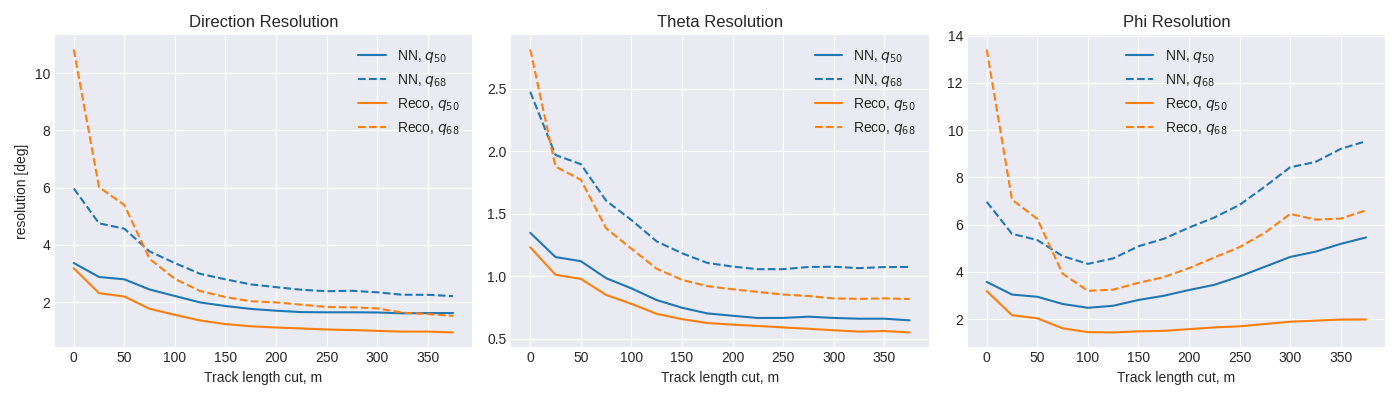

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

track_cuts = np.arange(0., 400., 25)

# Для хранения по track_cut
dirq50_nn, dirq68_nn = [], []
thetaq50_nn, thetaq68_nn = [], []
phiq50_nn, phiq68_nn = [], []

dirq50_reco, dirq68_reco = [], []
thetaq50_reco, thetaq68_reco = [], []
phiq50_reco, phiq68_reco = [], []

for track_cut in tqdm(track_cuts):
    cut = (event_properties_hist["track_lengths"] >= track_cut-0.01)
    # NN
    scalar_metrics_nn, vec_metrics_nn = angle_reconstruction_metrics(
        y_pred_hist[cut], y_true_hist[cut], True)
    dirq50_nn.append(scalar_metrics_nn['dir_resolution_q50'])
    dirq68_nn.append(scalar_metrics_nn['dir_resolution_q68'])
    thetaq50_nn.append(scalar_metrics_nn['theta_resolution_q50'])
    thetaq68_nn.append(scalar_metrics_nn['theta_resolution_q68'])
    phiq50_nn.append(scalar_metrics_nn['phi_resolution_q50'])
    phiq68_nn.append(scalar_metrics_nn['phi_resolution_q68'])
    # Reco
    _, y_pred_reco_hist, _ = AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
    scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(
        y_pred_reco_hist[cut], y_true_hist[cut], True)
    dirq50_reco.append(scalar_metrics_reco['dir_resolution_q50'])
    dirq68_reco.append(scalar_metrics_reco['dir_resolution_q68'])
    thetaq50_reco.append(scalar_metrics_reco['theta_resolution_q50'])
    thetaq68_reco.append(scalar_metrics_reco['theta_resolution_q68'])
    phiq50_reco.append(scalar_metrics_reco['phi_resolution_q50'])
    phiq68_reco.append(scalar_metrics_reco['phi_resolution_q68'])

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
colors = ['C0', 'C1']  # C0 - NN, C1 - reco

# 1. Direction
axs[0].plot(track_cuts, dirq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[0].plot(track_cuts, dirq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[0].set_title('Direction Resolution')
axs[0].set_ylabel('resolution [deg]')
axs[0].grid(True)
axs[0].legend()

# 2. Theta
axs[1].plot(track_cuts, thetaq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[1].plot(track_cuts, thetaq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[1].set_title('Theta Resolution')
axs[1].grid(True)
axs[1].legend()

# 3. Phi
axs[2].plot(track_cuts, phiq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[2].plot(track_cuts, phiq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[2].set_title('Phi Resolution')
axs[2].grid(True)
axs[2].legend()


for ax in axs:
    ax.set_xlabel('Track length cut, m')
plt.tight_layout()
plt.show()


(array([  155.,  1270.,  4529.,  9200., 12484., 13721.,  9239.,  5002.,
         2552.,  1158.]),
 array([1.48655879, 2.13780308, 2.78904748, 3.44029188, 4.09153605,
        4.74278069, 5.39402485, 6.04526949, 6.69651365, 7.34775829,
        7.99900246]),
 <BarContainer object of 10 artists>)

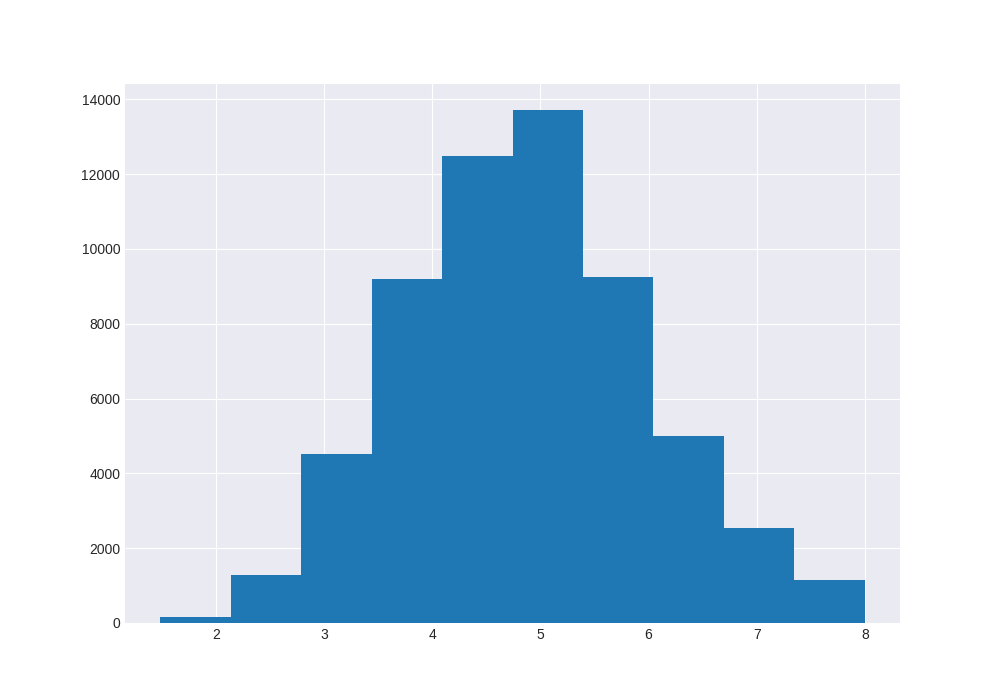

In [43]:
fig, ax = plt.subplots(figsize=[10, 7])
ax.hist(np.log10(event_properties_hist["energy"]))

100%|█████████████████████████████████████| 16/16 [00:24<00:00,  1.56s/it]


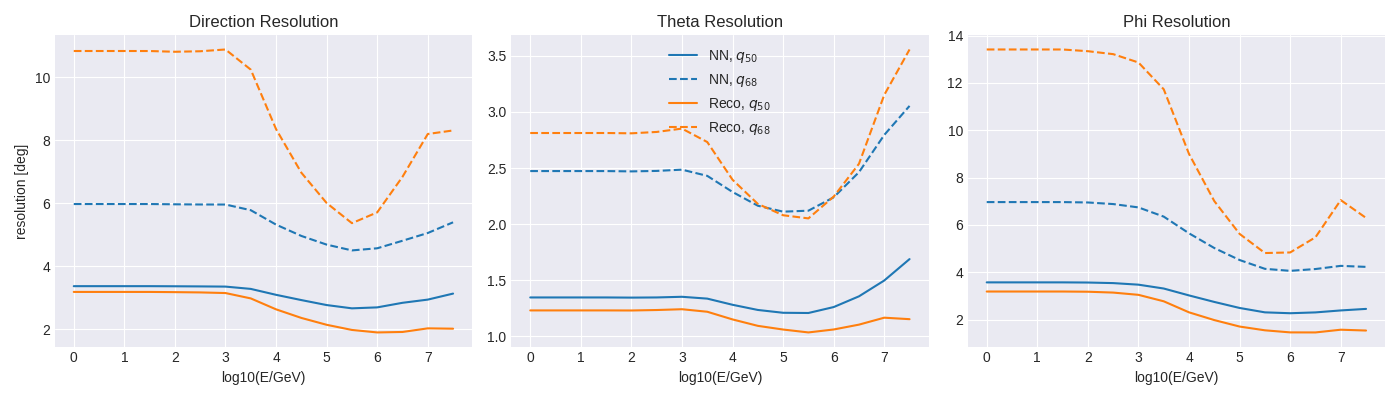

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

energy_cuts = np.arange(0., 8., 0.5)

# Для хранения по track_cut
dirq50_nn, dirq68_nn = [], []
thetaq50_nn, thetaq68_nn = [], []
phiq50_nn, phiq68_nn = [], []

dirq50_reco, dirq68_reco = [], []
thetaq50_reco, thetaq68_reco = [], []
phiq50_reco, phiq68_reco = [], []

for energy_cut in tqdm(energy_cuts):
    cut = (np.log10(event_properties_hist["energy"]) >= energy_cut-0.01) & (event_properties_hist["track_lengths"] >= -1)
    # NN
    scalar_metrics_nn, vec_metrics_nn = angle_reconstruction_metrics(
        y_pred_hist[cut], y_true_hist[cut], True)
    dirq50_nn.append(scalar_metrics_nn['dir_resolution_q50'])
    dirq68_nn.append(scalar_metrics_nn['dir_resolution_q68'])
    thetaq50_nn.append(scalar_metrics_nn['theta_resolution_q50'])
    thetaq68_nn.append(scalar_metrics_nn['theta_resolution_q68'])
    phiq50_nn.append(scalar_metrics_nn['phi_resolution_q50'])
    phiq68_nn.append(scalar_metrics_nn['phi_resolution_q68'])
    # Reco
    _, y_pred_reco_hist, _ = AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
    scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(
        y_pred_reco_hist[cut], y_true_hist[cut], True)
    dirq50_reco.append(scalar_metrics_reco['dir_resolution_q50'])
    dirq68_reco.append(scalar_metrics_reco['dir_resolution_q68'])
    thetaq50_reco.append(scalar_metrics_reco['theta_resolution_q50'])
    thetaq68_reco.append(scalar_metrics_reco['theta_resolution_q68'])
    phiq50_reco.append(scalar_metrics_reco['phi_resolution_q50'])
    phiq68_reco.append(scalar_metrics_reco['phi_resolution_q68'])

fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
colors = ['C0', 'C1']  # C0 - NN, C1 - reco

# 1. Direction
axs[0].plot(energy_cuts, dirq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[0].plot(energy_cuts, dirq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[0].plot(energy_cuts, dirq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[0].plot(energy_cuts, dirq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[0].set_title('Direction Resolution')
axs[0].set_ylabel('resolution [deg]')
axs[0].grid(True)
#axs[0].legend()

# 2. Theta
axs[1].plot(energy_cuts, thetaq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[1].plot(energy_cuts, thetaq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[1].plot(energy_cuts, thetaq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[1].plot(energy_cuts, thetaq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[1].set_title('Theta Resolution')
axs[1].grid(True)
axs[1].legend()

# 3. Phi
axs[2].plot(energy_cuts, phiq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[2].plot(energy_cuts, phiq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[2].plot(energy_cuts, phiq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[2].plot(energy_cuts, phiq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')
axs[2].set_title('Phi Resolution')
axs[2].grid(True)
# axs[2].legend()


for ax in axs:
    ax.set_xlabel('log10(E/GeV)')
plt.tight_layout()
plt.show()


NameError: name 'track_cuts' is not defined

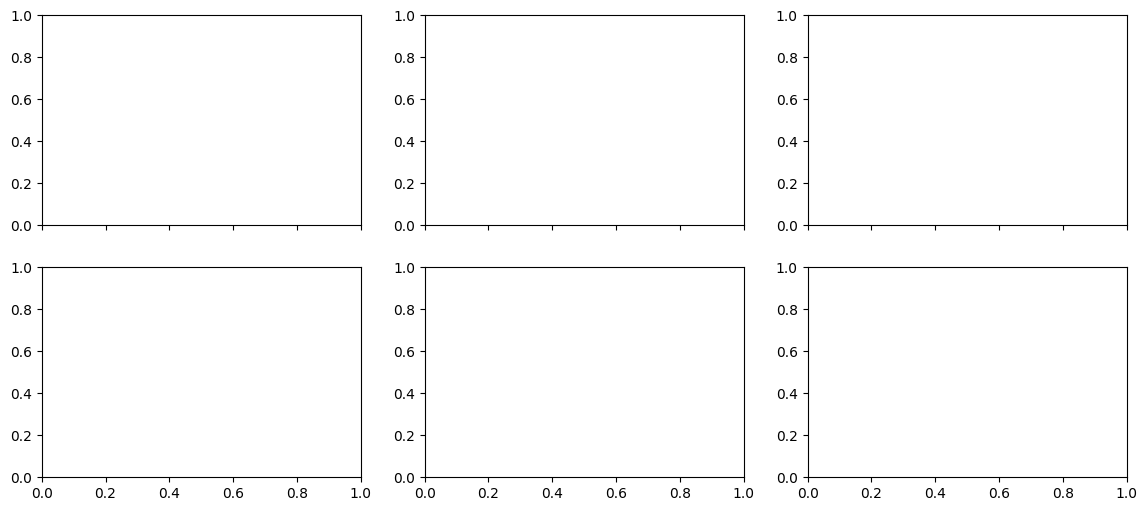

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Данные: dirq50_nn, dirq68_nn, ... (уже собраны)

fig, axs = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
colors = ['C0', 'C1']  # NN - C0, Reco - C1

# ===== q50 (верхняя строка) =====
# Direction
axs[0, 0].plot(track_cuts, dirq50_nn, color=colors[0], label='NN')
axs[0, 0].plot(track_cuts, dirq50_reco, color=colors[1], label='Reco')
axs[0, 0].set_title('Direction')
axs[0, 0].set_ylabel('resolution $q_{50}$ (deg)')
axs[0, 0].grid(True)

# Theta
axs[0, 1].plot(track_cuts, thetaq50_nn, color=colors[0], label='NN')
axs[0, 1].plot(track_cuts, thetaq50_reco, color=colors[1], label='Reco')
axs[0, 1].set_title('Theta')
axs[0, 1].grid(True)

# Phi
axs[0, 2].plot(track_cuts, phiq50_nn, color=colors[0], label='NN')
axs[0, 2].plot(track_cuts, phiq50_reco, color=colors[1], label='Reco')
axs[0, 2].set_title('Phi')
axs[0, 2].grid(True)

# ===== q68 (нижняя строка) =====
# Direction
axs[1, 0].plot(track_cuts, dirq68_nn, color=colors[0], label='NN')
axs[1, 0].plot(track_cuts, dirq68_reco, color=colors[1], label='Reco')
axs[1, 0].set_ylabel('resolution $q_{68}$ (deg)')
axs[1, 0].set_xlabel('Track length cut, m')
axs[1, 0].grid(True)

# Theta
axs[1, 1].plot(track_cuts, thetaq68_nn, color=colors[0], label='NN')
axs[1, 1].plot(track_cuts, thetaq68_reco, color=colors[1], label='Reco')
axs[1, 1].set_xlabel('Track length cut, m')
axs[1, 1].grid(True)

# Phi
axs[1, 2].plot(track_cuts, phiq68_nn, color=colors[0], label='NN')
axs[1, 2].plot(track_cuts, phiq68_reco, color=colors[1], label='Reco')
axs[1, 2].set_xlabel('Track length cut, m')
axs[1, 2].grid(True)

# ===== Легенды (только одна на строку) =====
handles0, labels0 = axs[0, 0].get_legend_handles_labels()
handles1, labels1 = axs[1, 0].get_legend_handles_labels()
axs[0, 0].legend(handles0, labels0, loc='upper right', frameon=True)
# axs[1, 0].legend(handles1, labels1, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import stats

track_cuts = np.arange(0., 400., 25)

# Для хранения по track_cut
dirq50_nn, dirq68_nn = [], []
thetaq50_nn, thetaq68_nn = [], []
phiq50_nn, phiq68_nn = [], []

dirq50_reco, dirq68_reco = [], []
thetaq50_reco, thetaq68_reco = [], []
phiq50_reco, phiq68_reco = [], []

# Для доверительных интервалов
n_bootstrap = 20  # Количество бутстрап выборок
ci_level = 0.95    # Уровень доверия (95%)

# Словари для хранения данных доверительных интервалов
ci_data = {
    'dir_nn': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}},
    'theta_nn': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}},
    'phi_nn': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}},
    'dir_reco': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}},
    'theta_reco': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}},
    'phi_reco': {'q50': {'lower': [], 'upper': []}, 'q68': {'lower': [], 'upper': []}}
}

for track_cut in tqdm(track_cuts):
    cut = (event_properties_hist["track_lengths"] >= track_cut)
    
    # Отфильтрованные данные
    y_pred_filtered = y_pred_hist[cut]
    y_true_filtered = y_true_hist[cut]
    reco_angles_filtered = event_properties_hist['reco_angles'][cut]
    
    # Основные метрики
    scalar_metrics_nn, vec_metrics_nn = angle_reconstruction_metrics(
        y_pred_filtered, y_true_filtered, True)
    
    _, y_pred_reco_filtered, _ = AnglePreprocessor()(_, reco_angles_filtered, _)
    scalar_metrics_reco, vec_metrics_reco = angle_reconstruction_metrics(
        y_pred_reco_filtered, y_true_filtered, True)
    
    # Сохраняем основные значения
    dirq50_nn.append(scalar_metrics_nn['dir_resolution_q50'])
    dirq68_nn.append(scalar_metrics_nn['dir_resolution_q68'])
    thetaq50_nn.append(scalar_metrics_nn['theta_resolution_q50'])
    thetaq68_nn.append(scalar_metrics_nn['theta_resolution_q68'])
    phiq50_nn.append(scalar_metrics_nn['phi_resolution_q50'])
    phiq68_nn.append(scalar_metrics_nn['phi_resolution_q68'])
    
    dirq50_reco.append(scalar_metrics_reco['dir_resolution_q50'])
    dirq68_reco.append(scalar_metrics_reco['dir_resolution_q68'])
    thetaq50_reco.append(scalar_metrics_reco['theta_resolution_q50'])
    thetaq68_reco.append(scalar_metrics_reco['theta_resolution_q68'])
    phiq50_reco.append(scalar_metrics_reco['phi_resolution_q50'])
    phiq68_reco.append(scalar_metrics_reco['phi_resolution_q68'])
    
    # Рассчитываем доверительные интервалы с помощью бутстрапа
    n_samples = len(y_true_filtered)
    
    # Только если есть достаточно данных для бутстрапа
    if n_samples > 10:
        # Массивы для хранения всех бутстрап-оценок
        bootstrap_values = {
            'dir_nn_q50': [], 'dir_nn_q68': [],
            'theta_nn_q50': [], 'theta_nn_q68': [],
            'phi_nn_q50': [], 'phi_nn_q68': [],
            'dir_reco_q50': [], 'dir_reco_q68': [],
            'theta_reco_q50': [], 'theta_reco_q68': [],
            'phi_reco_q50': [], 'phi_reco_q68': []
        }
        
        for _ in range(n_bootstrap):
            # Генерируем индексы для бутстрап-выборки
            indices = np.random.choice(n_samples, n_samples, replace=True)
            
            # NN метрики на бутстрап выборке
            boot_metrics_nn, _ = angle_reconstruction_metrics(
                y_pred_filtered[indices], y_true_filtered[indices], True)
            
            # Reco метрики на бутстрап выборке
            _, boot_pred_reco, _ = AnglePreprocessor()(_, reco_angles_filtered[indices], _)
            boot_metrics_reco, _ = angle_reconstruction_metrics(
                boot_pred_reco, y_true_filtered[indices], True)
            
            # Сохраняем значения
            bootstrap_values['dir_nn_q50'].append(boot_metrics_nn['dir_resolution_q50'])
            bootstrap_values['dir_nn_q68'].append(boot_metrics_nn['dir_resolution_q68'])
            bootstrap_values['theta_nn_q50'].append(boot_metrics_nn['theta_resolution_q50'])
            bootstrap_values['theta_nn_q68'].append(boot_metrics_nn['theta_resolution_q68'])
            bootstrap_values['phi_nn_q50'].append(boot_metrics_nn['phi_resolution_q50'])
            bootstrap_values['phi_nn_q68'].append(boot_metrics_nn['phi_resolution_q68'])
            
            bootstrap_values['dir_reco_q50'].append(boot_metrics_reco['dir_resolution_q50'])
            bootstrap_values['dir_reco_q68'].append(boot_metrics_reco['dir_resolution_q68'])
            bootstrap_values['theta_reco_q50'].append(boot_metrics_reco['theta_resolution_q50'])
            bootstrap_values['theta_reco_q68'].append(boot_metrics_reco['theta_resolution_q68'])
            bootstrap_values['phi_reco_q50'].append(boot_metrics_reco['phi_resolution_q50'])
            bootstrap_values['phi_reco_q68'].append(boot_metrics_reco['phi_resolution_q68'])
        
        # Вычисляем доверительные интервалы
        alpha = (1 - ci_level) / 2
        for key, values in bootstrap_values.items():
            # Разбираем ключ
            parts = key.split('_')
            metric = parts[0]
            model = parts[1]
            quantile = parts[2]
            
            lower, upper = np.percentile(values, [100*alpha, 100*(1-alpha)])
            ci_data[f'{metric}_{model}'][quantile]['lower'].append(lower)
            ci_data[f'{metric}_{model}'][quantile]['upper'].append(upper)
    else:
        # Добавляем None если недостаточно данных
        for metric in ['dir', 'theta', 'phi']:
            for model in ['nn', 'reco']:
                for quantile in ['q50', 'q68']:
                    ci_data[f'{metric}_{model}'][quantile]['lower'].append(None)
                    ci_data[f'{metric}_{model}'][quantile]['upper'].append(None)

 12%|████▊                                 | 2/16 [02:08<14:56, 64.02s/it]


KeyboardInterrupt: 

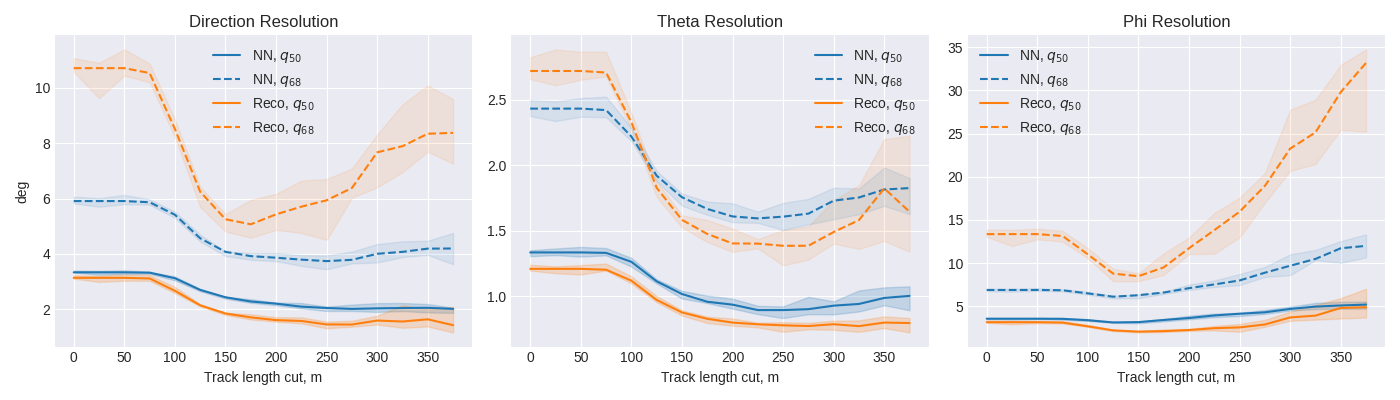

In [132]:
# Построение графиков
fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
colors = ['C0', 'C1']  # C0 - NN, C1 - reco

# 1. Direction
axs[0].plot(track_cuts, dirq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[0].plot(track_cuts, dirq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[0].plot(track_cuts, dirq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')

# Добавляем доверительные интервалы
axs[0].fill_between(track_cuts, ci_data['dir_nn']['q50']['lower'], ci_data['dir_nn']['q50']['upper'], 
                   color=colors[0], alpha=0.2)
axs[0].fill_between(track_cuts, ci_data['dir_nn']['q68']['lower'], ci_data['dir_nn']['q68']['upper'], 
                   color=colors[0], alpha=0.1)
axs[0].fill_between(track_cuts, ci_data['dir_reco']['q50']['lower'], ci_data['dir_reco']['q50']['upper'], 
                   color=colors[1], alpha=0.2)
axs[0].fill_between(track_cuts, ci_data['dir_reco']['q68']['lower'], ci_data['dir_reco']['q68']['upper'], 
                   color=colors[1], alpha=0.1)

axs[0].set_title('Direction Resolution')
axs[0].set_ylabel('deg')
axs[0].grid(True)
axs[0].legend()

# 2. Theta
axs[1].plot(track_cuts, thetaq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[1].plot(track_cuts, thetaq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[1].plot(track_cuts, thetaq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')

# Добавляем доверительные интервалы
axs[1].fill_between(track_cuts, ci_data['theta_nn']['q50']['lower'], ci_data['theta_nn']['q50']['upper'], 
                   color=colors[0], alpha=0.2)
axs[1].fill_between(track_cuts, ci_data['theta_nn']['q68']['lower'], ci_data['theta_nn']['q68']['upper'], 
                   color=colors[0], alpha=0.1)
axs[1].fill_between(track_cuts, ci_data['theta_reco']['q50']['lower'], ci_data['theta_reco']['q50']['upper'], 
                   color=colors[1], alpha=0.2)
axs[1].fill_between(track_cuts, ci_data['theta_reco']['q68']['lower'], ci_data['theta_reco']['q68']['upper'], 
                   color=colors[1], alpha=0.1)

axs[1].set_title('Theta Resolution')
axs[1].grid(True)
axs[1].legend()

# 3. Phi
axs[2].plot(track_cuts, phiq50_nn, color=colors[0], label='NN, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_nn, color=colors[0], label='NN, $q_{68}$', ls='--')
axs[2].plot(track_cuts, phiq50_reco, color=colors[1], label='Reco, $q_{50}$', ls='-')
axs[2].plot(track_cuts, phiq68_reco, color=colors[1], label='Reco, $q_{68}$', ls='--')

# Добавляем доверительные интервалы
axs[2].fill_between(track_cuts, ci_data['phi_nn']['q50']['lower'], ci_data['phi_nn']['q50']['upper'], 
                   color=colors[0], alpha=0.2)
axs[2].fill_between(track_cuts, ci_data['phi_nn']['q68']['lower'], ci_data['phi_nn']['q68']['upper'], 
                   color=colors[0], alpha=0.1)
axs[2].fill_between(track_cuts, ci_data['phi_reco']['q50']['lower'], ci_data['phi_reco']['q50']['upper'], 
                   color=colors[1], alpha=0.2)
axs[2].fill_between(track_cuts, ci_data['phi_reco']['q68']['lower'], ci_data['phi_reco']['q68']['upper'], 
                   color=colors[1], alpha=0.1)

axs[2].set_title('Phi Resolution')
axs[2].grid(True)
axs[2].legend()

for ax in axs:
    ax.set_xlabel('Track length cut, m')
    
plt.tight_layout()
plt.savefig('resolution_vs_tracklength.png', dpi=300)
plt.show()

100%|█████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 12.89it/s]


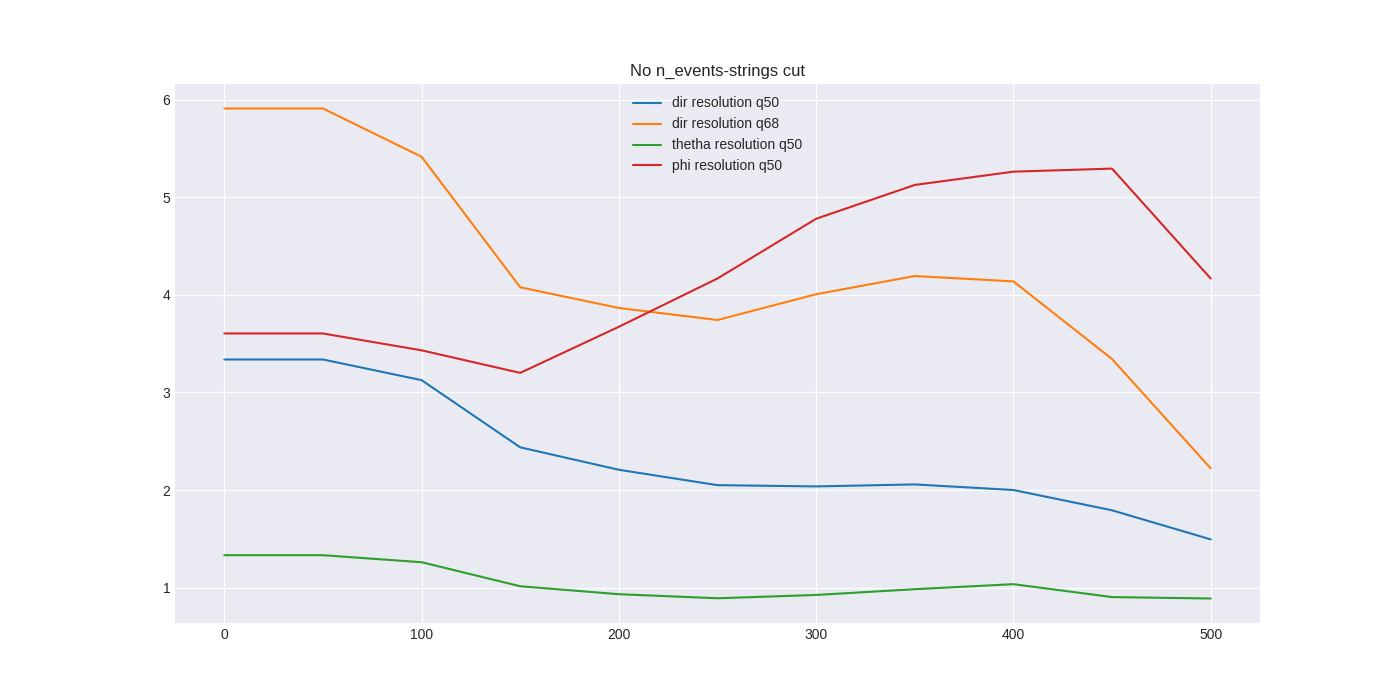

In [88]:
track_cuts = np.arange(0., max(event_properties_hist["track_lengths"]), 50)

fig, axs = plt.subplots(figsize=[14, 7], nrows=1, ncols=1)

for i in range(1):
    dir_res = []
    dir_res68 = []
    th_res = []
    ph_res = []
    num_events = []
    title = None
    for track_cut in tqdm(track_cuts):
        if i == 0:
            cut = (event_properties_hist["track_lengths"] >= track_cut)
            title = "No n_events-strings cut"
        num_events.append(cut.sum())
        metrics, _ = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut], False)
        dir_res.append(metrics['dir_resoultion_q50'])
        # dir_res68.append(metrics['dir_resoultion_q68'])
        th_res.append(metrics['theta_resolution_q50'])
        ph_res.append(metrics['phi_resolution_q50'])
    ax = axs
    # ax2 = axs[1]
    # ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
    # ax2.legend()
    ax.grid()
    ax.plot(track_cuts, dir_res, label='dir resolution q50')
    ax.plot(track_cuts, dir_res68, label='dir resolution q68')
    ax.plot(track_cuts, th_res, label='thetha resolution q50')
    ax.plot(track_cuts, ph_res, label='phi resolution q50')
    ax.grid()
    ax.legend()
    ax.set_title(title)
    # ax.set_yticks(np.arange(0, 5, 0.25))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  5.99it/s]


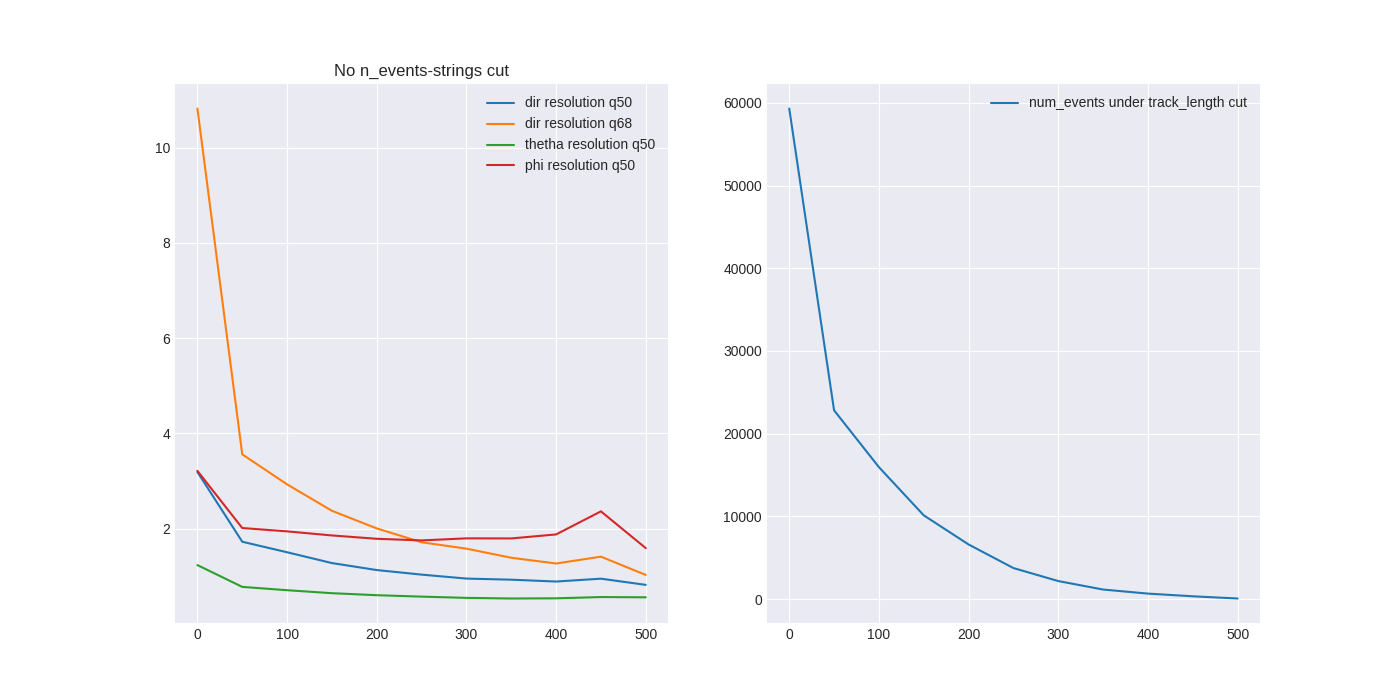

In [309]:
track_cuts = np.arange(0., max(event_properties_hist["track_lengths"]), 50)

fig, axs = plt.subplots(figsize=[14, 7], nrows=1, ncols=2)

for i in range(1):
    dir_res = []
    dir_res68 = []
    th_res = []
    ph_res = []
    num_events = []
    title = None
    for track_cut in tqdm(track_cuts):
        if i == 0:
            cut = (event_properties_hist["track_lengths"] >= track_cut)
            title = "No n_events-strings cut"
        num_events.append(cut.sum())
        metrics, _ = angle_reconstruction_metrics(y_pred_reco_hist[cut], y_true_hist[cut], False)
        dir_res.append(metrics['dir_resoultion_q50'])
        dir_res68.append(metrics['dir_resoultion_q68'])
        th_res.append(metrics['theta_resolution_q50'])
        ph_res.append(metrics['phi_resolution_q50'])
    ax = axs[0]
    ax2 = axs[1]
    ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
    ax2.legend()
    ax.grid()
    ax.plot(track_cuts, dir_res, label='dir resolution q50')
    ax.plot(track_cuts, dir_res68, label='dir resolution q68')
    ax.plot(track_cuts, th_res, label='thetha resolution q50')
    ax.plot(track_cuts, ph_res, label='phi resolution q50')
    ax.grid()
    ax.legend()
    ax.set_title(title)
    # ax.set_yticks(np.arange(0, 5, 0.25))

In [29]:
event_properties_hist.keys()

dict_keys(['num_strings', 'num_events', 'energy', 'track_lengths', 'reco_angles', 'reco_track_length', 'track_lengths_pred'])

In [31]:
import matplotlib.pyplot as plt

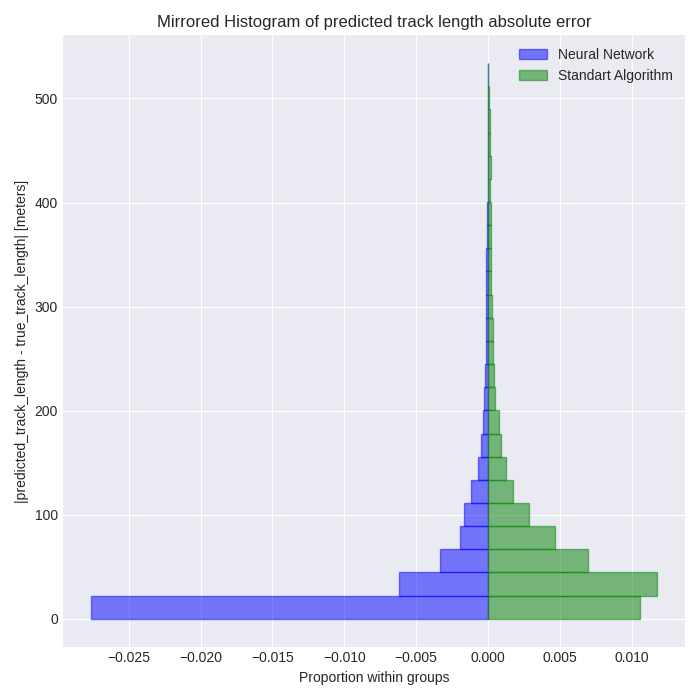

In [72]:
track_lenth_error = torch.abs(event_properties_hist["track_lengths"] - event_properties_hist["track_lengths_pred"])
track_lenth_error_reco = torch.abs(event_properties_hist["track_lengths"] - event_properties_hist["reco_track_length"])

x1 = np.array(track_lenth_error)
x2 = np.array(track_lenth_error_reco)

bins = np.linspace(0, max(x1.max(), x2.max()), 25)

hist1, edges = np.histogram(x1, bins=bins, density=True)
hist2, _ = np.histogram(x2, bins=bins, density=True)

bin_centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(7, 7))
plt.barh(bin_centers, -hist1, height=(bins[1]-bins[0]), color='blue', alpha=0.5, edgecolor='blue', label='Neural Network')
plt.barh(bin_centers, hist2, height=(bins[1]-bins[0]), color='green', alpha=0.5, edgecolor='green', label='Standart Algorithm')
plt.xlabel('Proportion within groups')
plt.ylabel('|predicted_track_length - true_track_length| [meters]')
plt.legend(loc='upper right')
plt.title('Mirrored Histogram of predicted track length absolute error')
plt.tight_layout()
plt.show()


In [64]:
event_properties_hist.keys()

dict_keys(['num_strings', 'num_events', 'energy', 'track_lengths', 'reco_angles', 'reco_track_length', 'track_lengths_pred'])

In [83]:
event_properties_hist.keys()

dict_keys(['num_strings', 'num_events', 'energy', 'track_lengths', 'track_lengths_by_tres', 'reco_angles', 'reco_track_lengths', 'track_lengths_pred'])

In [147]:
event_properties_hist.keys()

dict_keys(['num_strings', 'num_events', 'energy', 'track_lengths', 'track_lengths_by_tres', 'reco_angles', 'reco_track_lengths', 'track_lengths_pred_by_thr'])

In [ ]:
x0

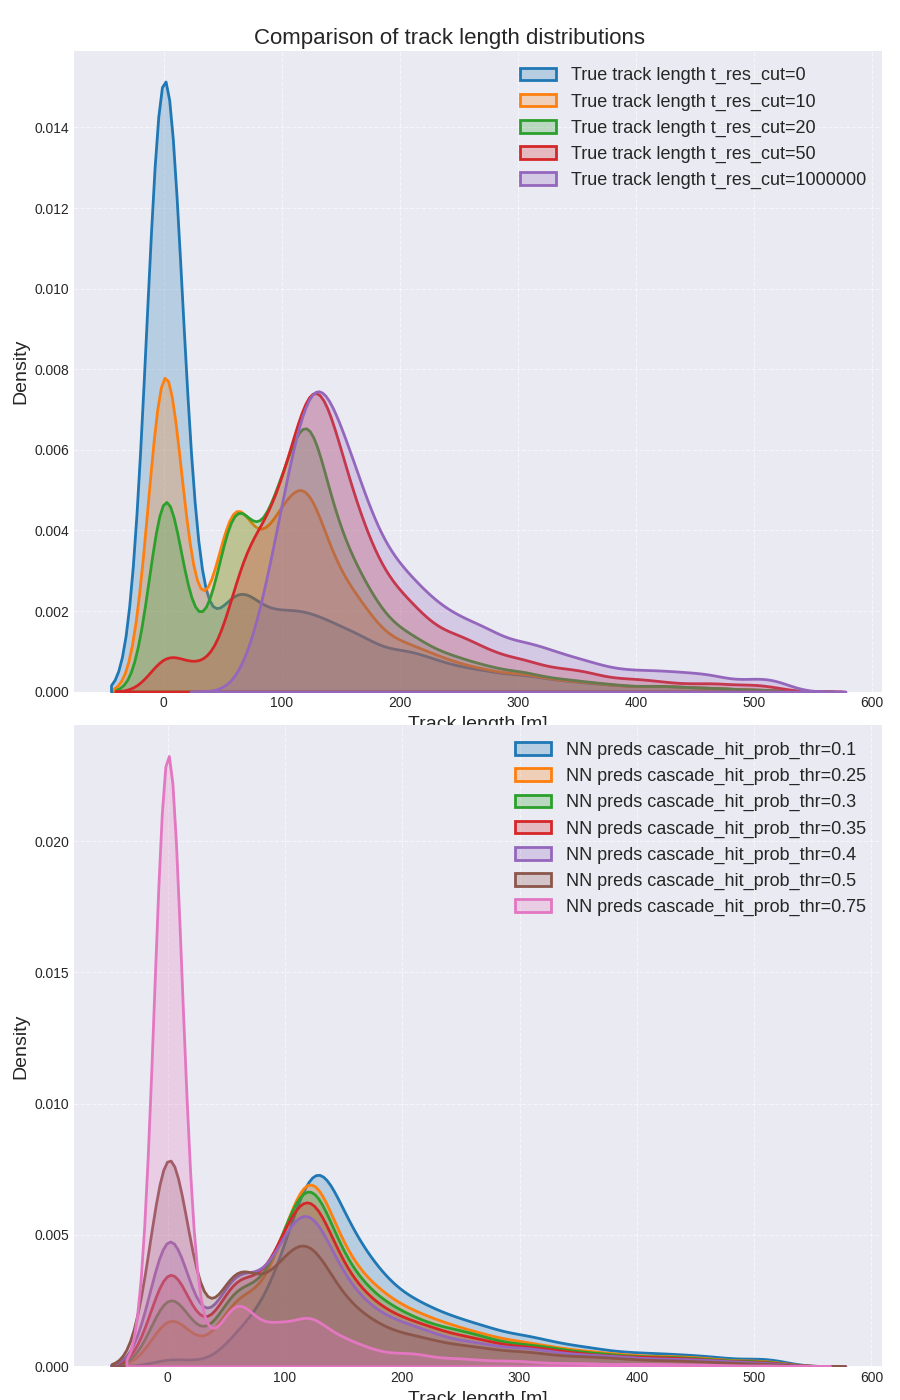

In [59]:
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(figsize=(9, 14), nrows=2)

track_lengths_by_tres = event_properties_hist["track_lengths_by_tres"]
for tres in track_lengths_by_tres:
    sns.kdeplot(
        track_lengths_by_tres[tres], fill=True, label=f"True track length t_res_cut={tres}",
        alpha=0.25, linewidth=2, ax=ax1)
    
track_lengths_pred_by_thr = event_properties_hist["track_lengths_pred_by_thr"]
for thr in list(track_lengths_pred_by_thr):
    sns.kdeplot(
        track_lengths_pred_by_thr[thr], fill=True, label=f"NN preds cascade_hit_prob_thr={thr}",
        alpha=0.25, linewidth=2, ax=ax2)

fig.suptitle('Comparison of track length distributions', fontsize=16)
fig.tight_layout()

for ax in (ax1, ax2):
    ax.set_xlabel('Track length [m]', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.legend(fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.6)
plt.show()
    # ax.savefig("plots/track_length_preds_distr_tres10.png")

In [44]:
gt = event_properties_hist["track_lengths_by_tres"][10]

for thr in list(track_lengths_pred_by_thr):
    mae = np.abs(gt - track_lengths_pred_by_thr[thr]).mean()
    print(f"thr={thr} mae={mae:.3f}")

thr=0.1 mae=87.286
thr=0.25 mae=64.074
thr=0.3 mae=56.959
thr=0.35 mae=51.222
thr=0.4 mae=46.954
thr=0.5 mae=44.489
thr=0.75 mae=70.219


In [45]:
x0 = np.array(event_properties_hist["track_lengths_pred"]) # largest distance between two points

KeyError: 'track_lengths_pred'

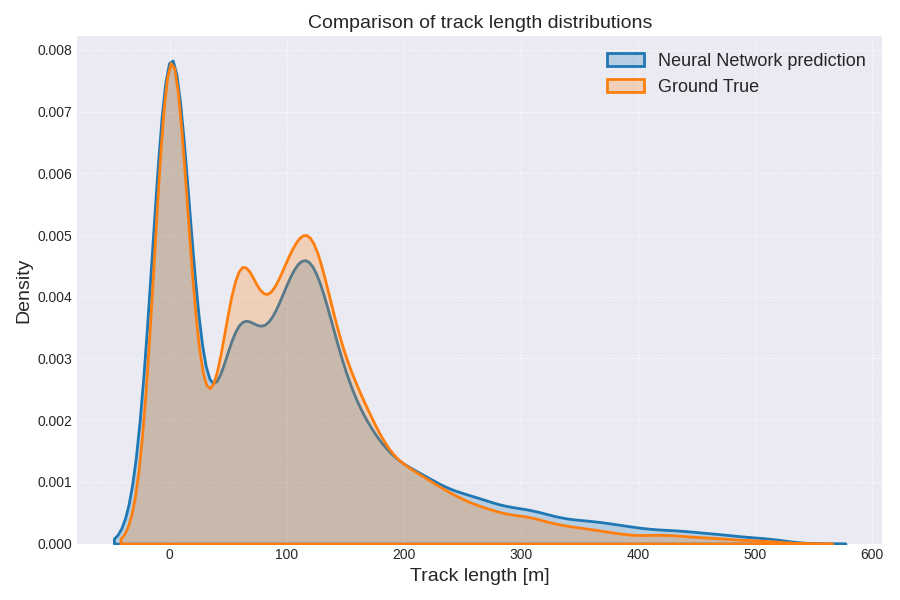

In [60]:
import seaborn as sns
x1 = np.array(event_properties_hist["track_lengths_pred_by_thr"][0.5])
# x2 = np.array(event_properties_hist["reco_track_lengths"])
x3 = np.array(event_properties_hist["track_lengths_by_tres"][10])

plt.figure(figsize=(9, 6))
# sns.kdeplot(x0, fill=True, label="Largest distance between two points in event", alpha=0.25, linewidth=2)
sns.kdeplot(x1, fill=True, label="Neural Network prediction", alpha=0.25, linewidth=2)
# sns.kdeplot(x2, fill=True, label="Reco prediction", alpha=0.25, linewidth=2)
sns.kdeplot(x3, fill=True, label="Ground True", alpha=0.25, linewidth=2)

plt.xlabel('Track length [m]', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Comparison of track length distributions', fontsize=14)
plt.legend(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.savefig("plots/track_length_preds_distr_tres10.png")

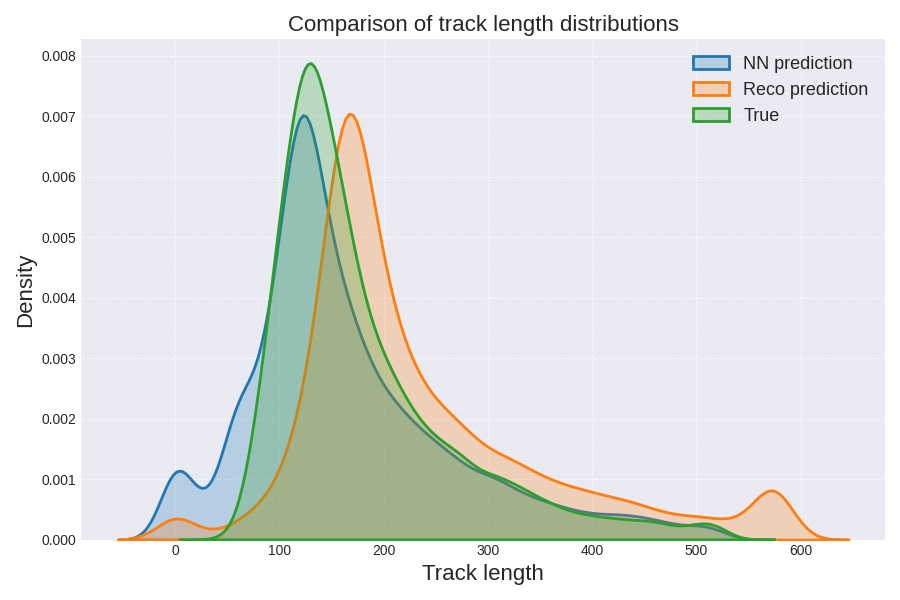

In [86]:
import seaborn as sns
x1 = np.array(event_properties_hist["track_lengths_pred"])
x2 = np.array(event_properties_hist["reco_track_lengths"])
x3 = np.array(event_properties_hist["track_lengths"])

plt.figure(figsize=(9, 6))
sns.kdeplot(x1, fill=True, label="NN prediction", alpha=0.25, linewidth=2)
sns.kdeplot(x2, fill=True, label="Reco prediction", alpha=0.25, linewidth=2)
sns.kdeplot(x3, fill=True, label="True", alpha=0.25, linewidth=2)

plt.xlabel('Track length', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.title('Comparison of track length distributions', fontsize=16)
plt.legend(fontsize=13)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.savefig("plots/track_length_preds_distr_tres10.png")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:01<00:00,  8.14it/s]


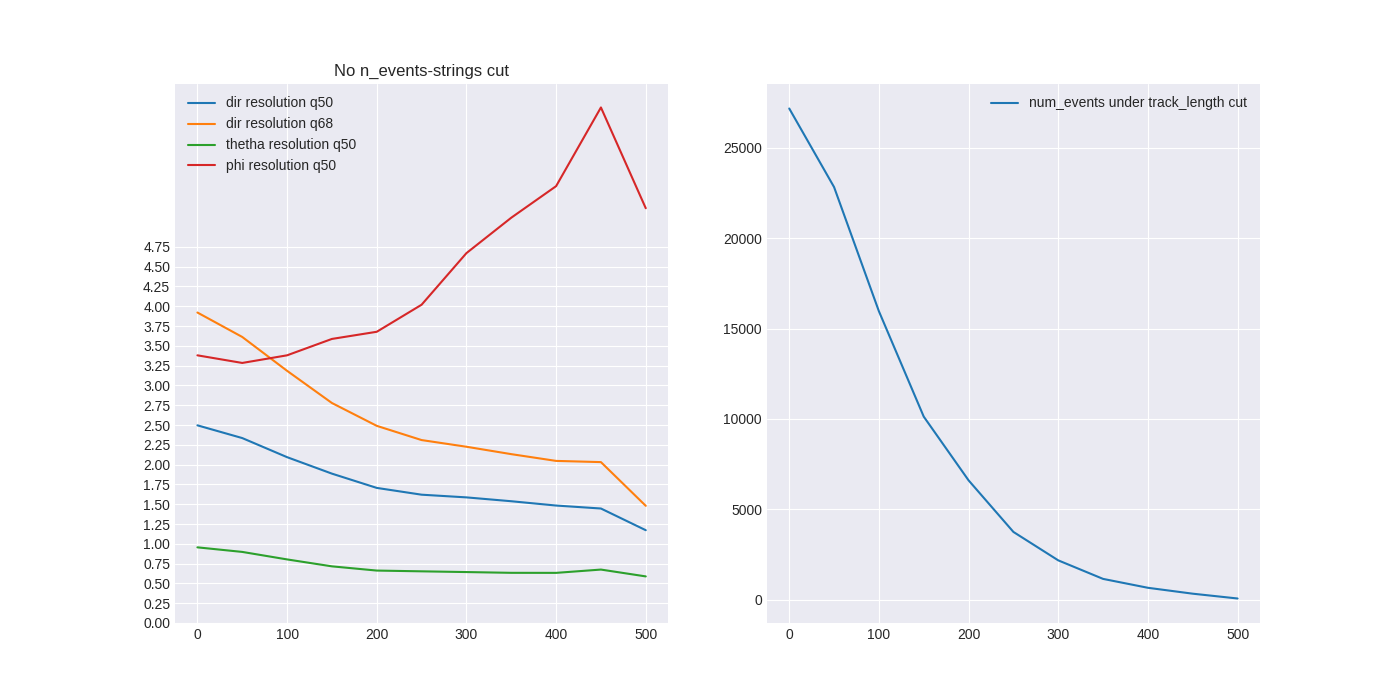

In [223]:
track_cuts = np.arange(0., max(event_properties_hist["track_lengths"]), 50)

fig, axs = plt.subplots(figsize=[14, 7], nrows=1, ncols=2)

# ax1.legend()
# ax1.grid()
# ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
# ax2.legend()
# ax1.set(xlabel="min track_length cut [m?]")
# ax1.st
for i in range(1):
    dir_res = []
    dir_res68 = []
    th_res = []
    ph_res = []
    num_events = []
    title = None
    for track_cut in tqdm(track_cuts):
        if i == 0:
            cut = (event_properties_hist["track_lengths"] > track_cut)
            title = "No n_events-strings cut"
        num_events.append(cut.sum())
        metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut])
        dir_res.append(metrics['dir_resoultion_q50'])
        dir_res68.append(metrics['dir_resoultion_q68'])
        th_res.append(metrics['theta_resolution_q50'])
        ph_res.append(metrics['phi_resolution_q50'])
    ax = axs[0]
    ax2 = axs[1]
    ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
    ax2.legend()
    ax.grid()
    ax.plot(track_cuts, dir_res, label='dir resolution q50')
    ax.plot(track_cuts, dir_res68, label='dir resolution q68')
    ax.plot(track_cuts, th_res, label='thetha resolution q50')
    ax.plot(track_cuts, ph_res, label='phi resolution q50')
    ax.grid()
    ax.legend()
    ax.set_title(title)
    ax.set_yticks(np.arange(0, 5, 0.25))

tensor([-0.1087, -0.0779, -0.1110, -0.1123, -0.1060, -0.1053, -0.0842, -0.0792,
        -0.0464, -0.1104, -0.1086, -0.1058, -0.1028, -0.1009, -0.1085, -0.0666,
        -0.0969, -0.0932, -0.1048, -0.0837, -0.0498, -0.0524, -0.0686, -0.0859,
        -0.1084,  0.0501, -0.0746, -0.0990,  0.0155, -0.1011, -0.1043, -0.0799,
        -0.0627, -0.1062, -0.0887, -0.1106, -0.0976, -0.1089, -0.1103, -0.1105,
        -0.0934, -0.0647, -0.0771, -0.1088, -0.1085, -0.0385, -0.0794, -0.1076,
        -0.1061, -0.1044, -0.0943, -0.0967, -0.0877, -0.1050, -0.1081, -0.1085,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.00

[Text(0.5, 0, 'min track_length cut [m?]')]

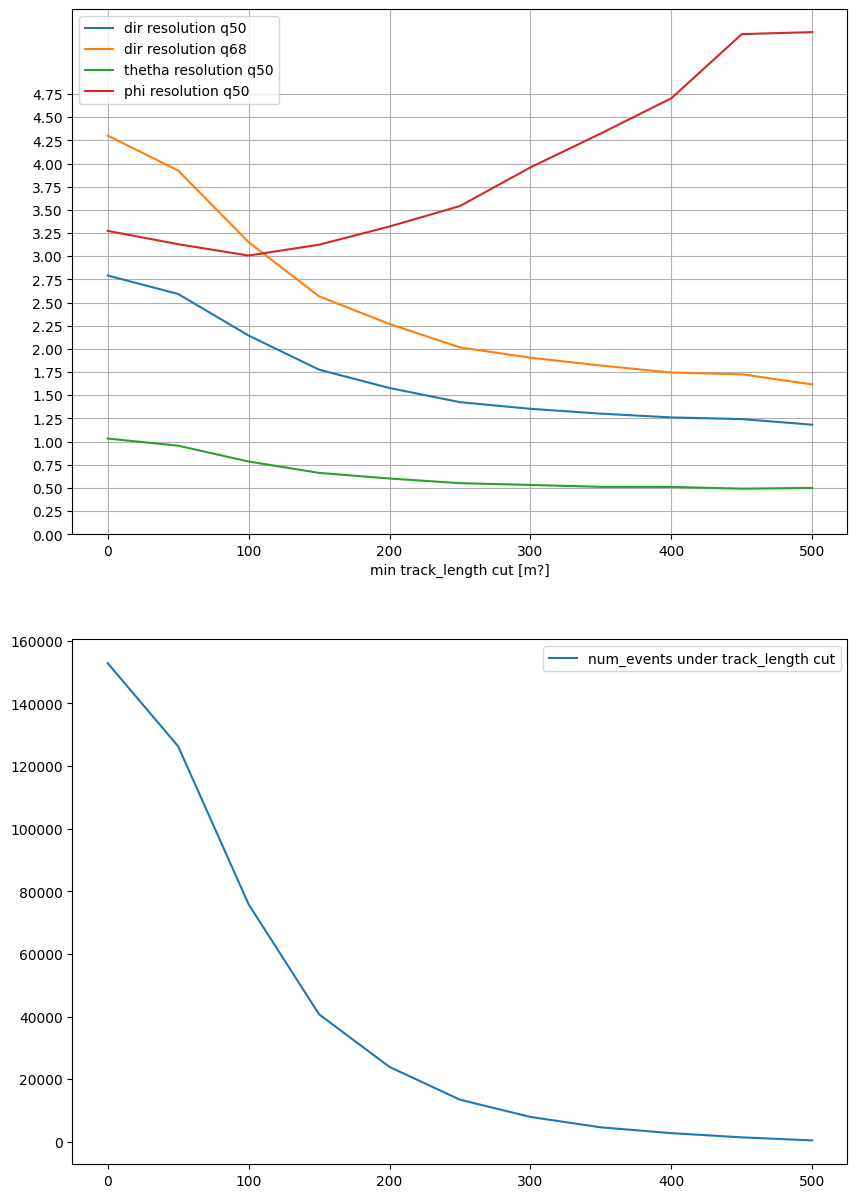

In [318]:
fig, (ax1, ax2) = plt.subplots(figsize=[10, 15], nrows=2)

ax1.plot(track_cuts, dir_res, label='dir resolution q50')
ax1.plot(track_cuts, dir_res68, label='dir resolution q68')
ax1.plot(track_cuts, th_res, label='thetha resolution q50')
ax1.plot(track_cuts, ph_res, label='phi resolution q50')
ax1.legend()
ax1.set_yticks(np.arange(0, 5, 0.25))
ax1.grid()
ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
ax2.legend()
ax1.set(xlabel="min track_length cut [m?]")

In [371]:
# predicted track length by track-cascade network

In [381]:
track_cuts = np.arange(0., max(event_properties_hist["track_lengths"]), 50)

dir_res = []
dir_res_pred = []

for track_cut in tqdm(track_cuts):
    cut = (event_properties_hist["track_lengths"] > track_cut)
    cut_pred = track_lengths_pred > track_cut
    num_events.append(cut.sum())
    metrics = angle_reconstruction_metrics(y_pred_hist[cut], y_true_hist[cut])
    metrics_pred = angle_reconstruction_metrics(y_pred_hist[cut_pred], y_true_hist[cut_pred])
    dir_res.append(metrics['dir_resoultion_q50'])
    dir_res_pred.append(metrics_pred['dir_resoultion_q50'])


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:19<00:00,  1.81s/it]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[Text(0.5, 0, 'min track_length cut [m?]')]

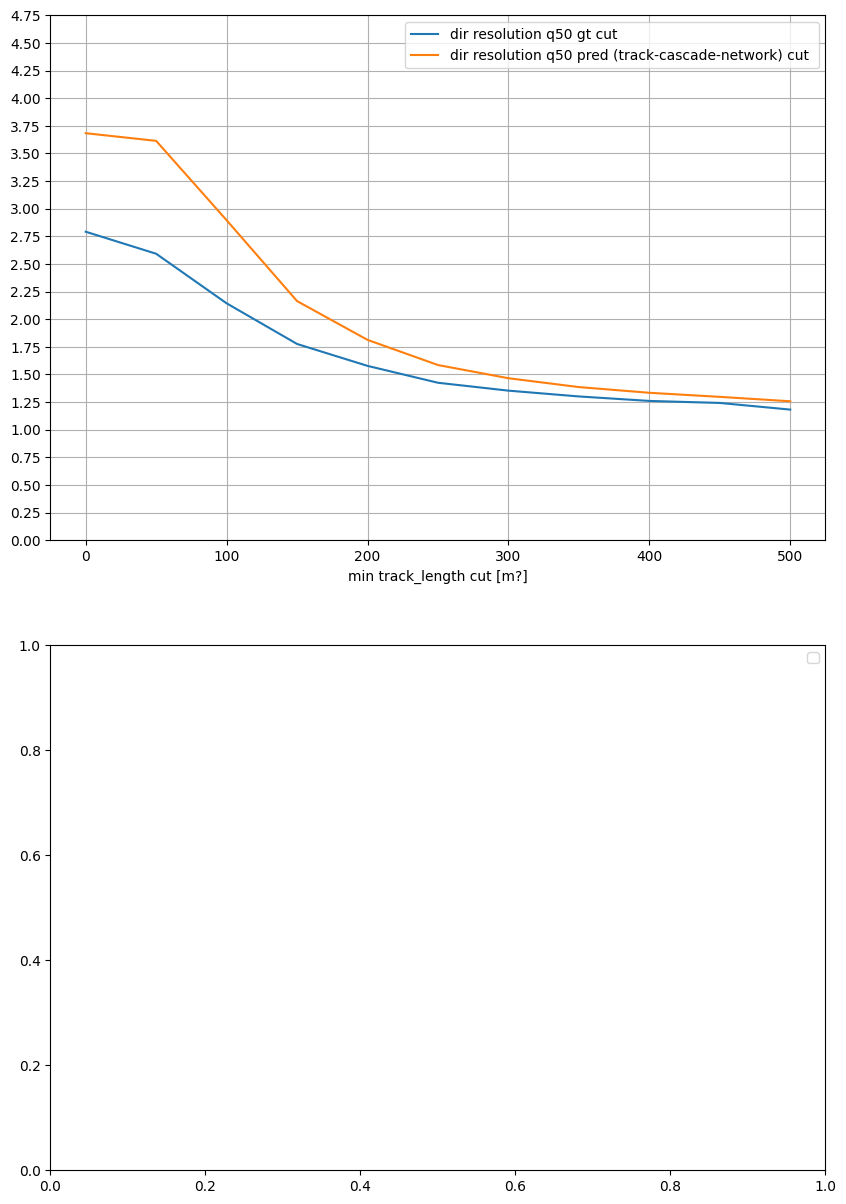

In [384]:
fig, (ax1, ax2) = plt.subplots(figsize=[10, 15], nrows=2)

ax1.plot(track_cuts, dir_res, label='dir resolution q50 gt cut ')
ax1.plot(track_cuts, dir_res_pred, label='dir resolution q50 pred (track-cascade-network) cut ')

ax1.legend()
ax1.set_yticks(np.arange(0, 5, 0.25))
ax1.grid()
# ax2.plot(track_cuts, num_events, label='num_events under track_length cut')
ax2.legend()
ax1.set(xlabel="min track_length cut [m?]")

In [112]:
# mask = 
# cut = (event_properties["num_strings"] >= 3) & (event_properties["num_events"] >= 10) & (event_properties['energy'] > 1e4)
cut = (event_properties_hist["track_lengths"] > 2)
y_pred_hist_cut = y_pred_hist[cut]
y_true_hist_cut = y_true_hist[cut]

In [113]:
angle_reconstruction_metrics(y_pred_hist, y_true_hist)

{'theta_mae': 3.384019613265991,
 'phi_mae': 18.863420486450195,
 'theta_resolution_q50': 1.3438873291015625,
 'theta_resolution_q68': 2.4699661254882814,
 'phi_resolution_q50': 3.6696929931640625,
 'phi_resolution_q68': 7.102951049804688,
 'dir_resoultion_q50': 3.447077989578247,
 'dir_resoultion_q68': 6.001961135864259}

In [115]:
event_properties_hist.keys()

dict_keys(['num_strings', 'num_events', 'energy', 'track_lengths', 'reco_angles', 'reco_track_length', 'track_lengths_pred'])

In [129]:
event_properties_hist['reco_track_length'].shape

torch.Size([2813044])

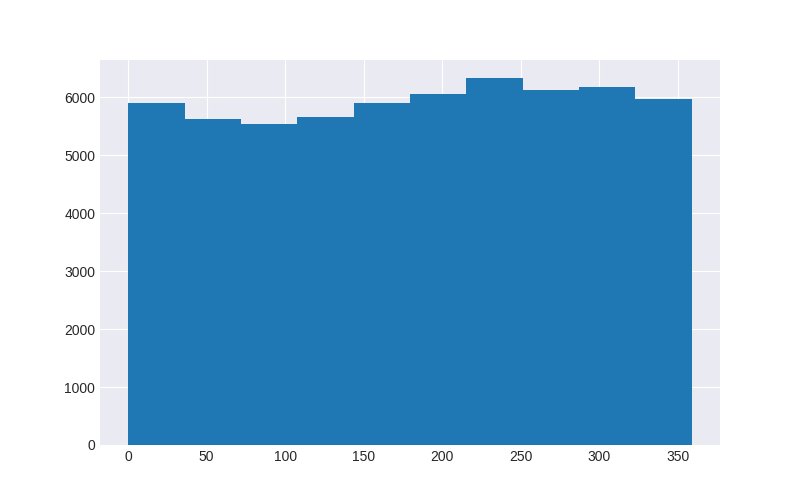

In [171]:
fig, ax = plt.subplots(figsize=[8, 5])
ax.hist(event_properties_hist['reco_angles'][:, 1])
plt.show()

In [202]:
def angle_to_vector(angles):
    thetha = np.deg2rad(angles[:, 0])
    phi = np.deg2rad(angles[:, 1])
    # print(y.shape, thetha.min(), thetha.max(), phi.min(), phi.max())
    angle = np.zeros((angles.shape[0], 3), dtype=np.float32)
    angle[:, 0] = np.sin(thetha) * np.cos(phi)
    angle[:, 1] = np.sin(thetha) * np.sin(phi)
    angle[:, 2] = np.cos(thetha)
    return angle

In [203]:
angles_true = np.array(dataset.hfile["test/prime_prty/data"][:, :2])

In [204]:
y_true_hist_v2 = angle_to_vector(angles_true)

In [205]:
y_reco_hist = angle_to_vector(event_properties_hist['reco_angles'])

In [206]:
y_reco_hist.shape

(59310, 3)

In [207]:
_, y_reco_hist, _ =  AnglePreprocessor()(_, event_properties_hist['reco_angles'], _)
y_reco_hist.shape, y_pred_hist.shape

In [214]:
angle_reconstruction_metrics(y_pred_hist, y_true_hist)

{'theta_mae': 3.284149408340454,
 'phi_mae': 18.072784423828125,
 'theta_resolution_q50': 1.3470487594604492,
 'theta_resolution_q68': 2.4740814208984374,
 'phi_resolution_q50': 3.5971927642822266,
 'phi_resolution_q68': 7.105892333984376,
 'dir_resoultion_q50': 3.3698484897613525,
 'dir_resoultion_q68': 5.974055290222169}

In [208]:
angle_reconstruction_metrics(y_pred_hist, y_true_hist)

{'theta_mae': 3.2788448333740234,
 'phi_mae': 18.072784423828125,
 'theta_resolution_q50': 1.3469715118408203,
 'theta_resolution_q68': 2.47351043701172,
 'phi_resolution_q50': 3.5971927642822266,
 'phi_resolution_q68': 7.105892333984376,
 'dir_resoultion_q50': 3.3698484897613525,
 'dir_resoultion_q68': 5.974055290222169}

In [215]:
angle_reconstruction_metrics(y_reco_hist, y_true_hist)

{'theta_mae': 6.990909099578857,
 'phi_mae': 33.31392288208008,
 'theta_resolution_q50': 1.2392311096191406,
 'theta_resolution_q68': 2.860475311279297,
 'phi_resolution_q50': 3.211772918701172,
 'phi_resolution_q68': 13.953795166015626,
 'dir_resoultion_q50': 3.187087297439575,
 'dir_resoultion_q68': 10.826321983337404}

In [210]:
angle_reconstruction_metrics(y_reco_hist, y_true_hist)

{'theta_mae': 6.386655330657959,
 'phi_mae': 33.31392288208008,
 'theta_resolution_q50': 1.231459617614746,
 'theta_resolution_q68': 2.8126452636718757,
 'phi_resolution_q50': 3.211772918701172,
 'phi_resolution_q68': 13.953795166015626,
 'dir_resoultion_q50': 3.187087297439575,
 'dir_resoultion_q68': 10.826321983337404}

In [111]:
angle_reconstruction_metrics(y_pred_hist_cut, y_true_hist_cut)

NameError: name 'y_pred_hist_cut' is not defined

In [87]:
# old val subset 1000
angle_reconstruction_metrics(y_pred_hist, y_true_hist)

NameError: name 'mean_absolute_error' is not defined

In [76]:
# old test
angle_reconstruction_metrics(y_pred_hist, y_true_hist)

{'theta_mae': 3.6204490661621094,
 'phi_mae': 23.48845672607422,
 'theta_resolution_q50': 2.5256271362304688,
 'theta_resolution_q68': 3.93642204284668,
 'phi_resolution_q50': 7.4243316650390625,
 'phi_resolution_q68': 11.948744506835938,
 'dir_resoultion_q50': 4.803832054138184,
 'dir_resoultion_q68': 6.677865600585937}

In [ ]:
def create_new_h5(old_h5, old_path, new_path):
    

In [212]:
angle_reconstruction_metrics(y_pred_hist_cut, y_true_hist_cut)

ValueError: NumPy boolean array indexing assignment cannot assign 2801 input values to the 0 output values where the mask is true

In [33]:
# num_string = 2

angle_reconstruction_metrics(y_pred_hist_cut, y_true_hist_cut)

{'theta_mae': 5.979598522186279,
 'phi_mae': 31.702219009399414,
 'theta_resolution_q50': 2.950240135192871,
 'theta_resolution_q68': 5.607605895996094,
 'phi_resolution_q50': 9.632862091064453,
 'phi_resolution_q68': 16.661854553222657,
 'dir_resoultion_q50': 8.135183334350586,
 'dir_resoultion_q68': 13.361407012939456}

In [47]:
angle_reconstruction_metrics(y_pred_hist_cut, y_true_hist_cut)

{'theta_mae': 34.75986862182617,
 'phi_mae': 45.814144134521484,
 'theta_resolution_q50': 30.136131286621094,
 'theta_resolution_q68': 46.94792358398438,
 'phi_resolution_q50': 17.934154510498047,
 'phi_resolution_q68': 30.446940917968753,
 'dir_resoultion_q50': 38.1024169921875,
 'dir_resoultion_q68': 54.825432128906264}

In [178]:
angle_reconstruction_metrics(y_pred_hist_cut, y_true_hist_cut)

{'theta_mae': 3.1690430641174316,
 'phi_mae': 12.565604209899902,
 'theta_resolution_q50': 2.0093116760253906,
 'theta_resolution_q68': 3.201993103027344,
 'phi_resolution_q50': 4.308197021484375,
 'phi_resolution_q68': 6.700780181884767,
 'dir_resoultion_q50': 4.434028148651123,
 'dir_resoultion_q68': 6.333143138885498}

In [179]:
#angle_reconstruction_metrics(y_pred_hist, y_true_hist)

{'theta_mae': 4.184208869934082,
 'phi_mae': 18.529006958007812,
 'theta_resolution_q50': 2.3200149536132812,
 'theta_resolution_q68': 3.8195800781250004,
 'phi_resolution_q50': 5.525063514709473,
 'phi_resolution_q68': 9.15766830444336,
 'dir_resoultion_q50': 5.376364469528198,
 'dir_resoultion_q68': 8.236653327941905}

no-cut
{'theta_mae': 4.184208869934082,
 'phi_mae': 18.529006958007812,
 'theta_resolution_q50': 2.3200149536132812,
 'theta_resolution_q68': 3.8195800781250004,
 'phi_resolution_q50': 5.525063514709473,
 'phi_resolution_q68': 9.15766830444336,
 'dir_resoultion_q50': 5.376364469528198,
 'dir_resoultion_q68': 8.236653327941905
 }

10-3
{'theta_mae': 3.1690430641174316,
 'phi_mae': 12.565604209899902,
 'theta_resolution_q50': 2.0093116760253906,
 'theta_resolution_q68': 3.201993103027344,
 'phi_resolution_q50': 4.308197021484375,
 'phi_resolution_q68': 6.700780181884767,
 'dir_resoultion_q50': 4.434028148651123,
 'dir_resoultion_q68': 6.333143138885498}



In [49]:
angles_true = np.array([extract_angles(vec) for vec in y_true_hist], dtype=np.float32)
angles_pred = np.array([extract_angles(vec) for vec in y_pred_hist], dtype=np.float32)
y_true_theta_angle, y_true_phi_angle = angles_true[:, 0], angles_true[:, 1]
y_pred_theta_angle, y_pred_phi_angle = angles_pred[:, 0], angles_pred[:, 1]

(array([1237., 2868., 2512., 2377., 2270.,  136., 1381., 2063., 1773.,
         791.]),
 array([  0.5211454 ,  18.44219589,  36.36324692,  54.28429413,
         72.20534515,  90.12639618, 108.0474472 , 125.9684906 ,
        143.88954163, 161.81059265, 179.73164368]),
 <BarContainer object of 10 artists>)

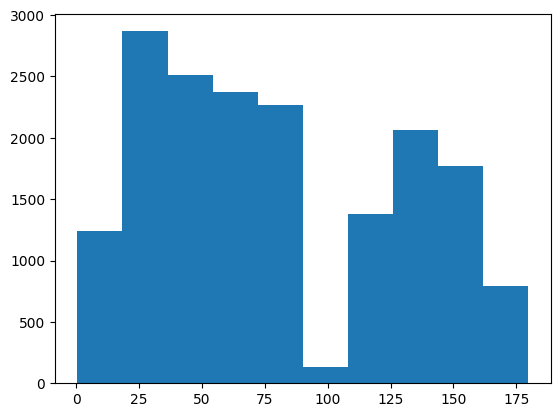

In [50]:
plt.hist(y_true_theta_angle)

In [57]:
############## clustering tmp

In [73]:
track

3072

In [34]:
train_params["path_to_data"]

'/home/plotnikovgp/baikal/data/baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed.h5'

In [ ]:
def create_cluster_dataset():
    for x in t

In [58]:
from sklearn.cluster import DBSCAN

# eps: maximum distance between points in same cluster
# min_samples: minimum points to form dense region
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X)

NameError: name 'X' is not defined